# PUMP ΓÇö region, sample and pump comparison

**Diagnostic notebook only:** inspect repeatability; no feature selection, model fitting, prediction, or changes to existing feature CSVs.

Choose one fault, state, region, signal/channel, and any pumps/samples in cell 2. Change the selection and rerun from cell 3 onward. To change only the pump shown in the within-pump plot, call its plotting function again with another pump number.

The notebook shows:
1. Full recordings with all changepoints/region labels, beside an enlarged selected region with division boundaries and six annotated feature values.
2. Division-to-division feature trends for every sample of one pump.
3. Sample-to-sample comparisons of the **same division** within that pump.
4. Comparisons between pumps for each corresponding division, showing individual samples, pump means and sample SD.
5. Six sample/division heatmaps and numerical within-pump/between-pump variation tables.

Region numbers start at **0**, divisions at **1**. For the selected fault/state/region/signal, find the shortest full region across **all pumps and samples**, including samples outside the display filters. Centre a window of that duration in every sample's region and divide it into equal-time parts. For example, a 3 s minimum and three divisions gives 1 s per division; a 10 s region contributes its central 3 s. `REGION_EDGE_SECONDS=0` uses full regions. If positive, subtract twice that value from each region before finding the minimum.

Time uses the existing row/sample-rate approximation. Row rounding can cause differences of up to approximately one sample interval in division duration. Shared duration does not imply equal row counts at different sampling rates. Missing/invalid reference recordings stop the scan rather than silently changing the minimum.

Six features: **RMS, standard deviation, MAD, q95, skewness and excess kurtosis**. The default reproduces the PUMP statistics notebook's 2.5ΓÇô97% quantile trimming and AC1/GYR median-centring rules; q95 and MAD retain the original definition. Set `TRIM_QUANTILES=None` for untrimmed diagnostic features. Raw plots always show untrimmed values. Units remain the CSV's units; no calibration is inferred.

Requirements: `numpy pandas polars scipy matplotlib tqdm`. Input: the combined PUMP metadata/timestamp CSVs **and the raw signal CSVs referenced by them**. Previously extracted feature tables cannot reconstruct within-region divisions.

In [26]:
import os
os.environ.setdefault("POLARS_MAX_THREADS", "1")
os.environ.setdefault("OMP_NUM_THREADS", "1")
import gc
from pathlib import Path
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
from tqdm.auto import tqdm
try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value.to_string() if isinstance(value, pd.DataFrame) else value)

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.18})
pd.set_option("display.max_columns", 30)

## 1. Choose the comparison

`PUMP_IDS=None` / `SAMPLE_IDS=None` includes all available IDs for the selected fault/state. IDs may be integers or strings. `FOCUS_PUMP=None` selects the first available pump for the within-pump plots; all selected pumps still enter the between-pump plots. The minimum always includes all pumps/samples for this fault/state, even when display filters are set. Set `REGION_EDGE_SECONDS=0` to include the entire changepoint interval, including transitions.

In [27]:
META_PATH = Path("pump_meta_combined_all_faults_mapped.csv")
TIMESTAMPS_PATH = Path("pump_signalwise_timestamp_combined.csv")
PATH_REPLACEMENTS = {}  # e.g. {r"D:\VGuard Ahemedebad Data": r"E:\PumpData"}

FAULT_ID = "00000000000_"
STATE = "water"          # "air" or "water"
REGION = 0               # Air: 0ΓÇô1; Water: 0ΓÇô3 for the supplied dataset
SIGNAL = "CV1"           # CV1, VRY, CTB, CTR, SMG, AC1, GYR, PRS or WTF
COLUMN = "0"             # AC1/GYR: 0/1/2; VRY: 0/1; others: 0
PUMP_IDS = None         # e.g. [1, 2, 3]
SAMPLE_IDS = None        # e.g. [1, 2, 3, 4, 5]
FOCUS_PUMP = None        # e.g. 1
N_DIVISIONS = 3
REGION_EDGE_SECONDS = 0.0  # Full shortest region; positive values trim both ends first
TRIM_QUANTILES = (0.025, 0.97)  # None = no outlier trimming
MIN_DIVISION_SAMPLES = 32

# Bound only plot previews; features use every original row in each division.
MAX_TRACE_POINTS = 10000
SAMPLES_PER_FIGURE = 3
SAVE_PLOTS = False
EXPORT_TABLES = False
OUTPUT_ROOT = Path("pump_comparison_outputs")

# Future merged-file equivalents: only established non-electrical names are
# prefilled. Explicitly configure electrical channels before comparing them.
NEW_RAW_COLUMNS = {
    "AC1": {"0": "ac1", "1": "ac2", "2": "ac3"},
    "GYR": {"0": "gy1", "1": "gy2", "2": "gy3"},
    "SMG": {"0": "mag"}, "PRS": {"0": "prs"}, "WTF": {"0": "wtf"},
    "CV1": {}, "VRY": {}, "CTB": {}, "CTR": {},
}

## 2. Inspect available faults and selected samples

No healthy/single-fault filter is applied: any fault in the metadata can be inspected. Air/Water pairing is not required for this single-state diagnostic.

In [28]:
FEATURES = ["mean","rms", "std", "mad", "q95", "skew", "kurt"]
LABELS = {"mean":"Mean","rms": "RMS", "std": "Standard deviation", "mad": "MAD",
          "q95": "95th percentile", "skew": "Skewness", "kurt": "Excess kurtosis"}

def normalize_id(value):
    number = float(value)
    if not np.isfinite(number) or number < 0 or number != int(number):
        raise ValueError(f"Expected a nonnegative integer pump/sample ID, got {value}")
    return str(int(number))

meta = pd.read_csv(META_PATH, dtype={"fault_id": str, "pump_id": str, "sample_id": str})
orig_ts = pd.read_csv(TIMESTAMPS_PATH, dtype=str)
meta["fault_id"] = meta["fault_id"].str.strip()
meta["state"] = meta["state"].str.strip().str.lower()
for col in ["pump_id", "sample_id"]:
    meta[col] = meta[col].map(normalize_id)
meta["sample_id_key"] = meta[["fault_id", "pump_id", "sample_id"]].agg("@".join, axis=1)
meta["state_id_key"] = meta["sample_id_key"] + "@" + meta["state"]
if meta["state_id_key"].duplicated().any() or orig_ts["id"].duplicated().any():
    raise ValueError("Duplicate sample/state or signalwise timestamp IDs")
orig_ts_lookup = dict(zip(orig_ts["id"], orig_ts["indices"]))
fault_inventory = meta.groupby(["fault_id", "state"]).agg(
    pumps=("pump_id", "nunique"), samples=("sample_id_key", "nunique")
).reset_index()
display(fault_inventory)

FAULT_ID, STATE, SIGNAL, COLUMN = str(FAULT_ID).strip(), STATE.strip().lower(), SIGNAL.upper(), str(COLUMN)
if STATE not in ["air", "water"]:
    raise ValueError("STATE must be air or water")
if not isinstance(N_DIVISIONS, int) or N_DIVISIONS < 1:
    raise ValueError("N_DIVISIONS must be a positive integer")
if not isinstance(REGION, int) or REGION < 0 or REGION_EDGE_SECONDS < 0:
    raise ValueError("REGION and REGION_EDGE_SECONDS must be nonnegative")
if MAX_TRACE_POINTS < 4 or SAMPLES_PER_FIGURE < 1 or MIN_DIVISION_SAMPLES < 4:
    raise ValueError("Invalid plot/division size settings")
if TRIM_QUANTILES is not None and not (0 <= TRIM_QUANTILES[0] < TRIM_QUANTILES[1] <= 1):
    raise ValueError("Invalid quantile bounds")
selected = meta[(meta["fault_id"] == FAULT_ID) & (meta["state"] == STATE)].copy()
all_fault_samples = selected.copy()  # Reference includes ALL pumps/samples before display filters.
for setting, col in [(PUMP_IDS, "pump_id"), (SAMPLE_IDS, "sample_id")]:
    if setting is not None:
        requested = {normalize_id(v) for v in setting}
        missing = requested - set(selected[col])
        if missing:
            raise ValueError(f"Requested {col} values not found: {sorted(missing)}")
        selected = selected[selected[col].isin(requested)]
if selected.empty:
    raise ValueError("No samples match this selection. Check the inventory above.")
if SIGNAL not in all_fault_samples or all_fault_samples[SIGNAL].isna().any():
    raise ValueError(f"{SIGNAL} is unavailable for one or more {STATE} samples; PRS/WTF are Water-only.")
selected = selected.sort_values(["pump_id", "sample_id"], key=lambda c: c.astype(int)).reset_index(drop=True)
focus_pump = normalize_id(FOCUS_PUMP) if FOCUS_PUMP is not None else selected.iloc[0]["pump_id"]
if focus_pump not in set(selected["pump_id"]):
    raise ValueError("FOCUS_PUMP is not in the selected pump list")
for row in all_fault_samples.itertuples():
    key = f"{SIGNAL}_{row.state_id_key}"
    if key not in orig_ts_lookup:
        raise ValueError(f"Missing changepoints: {key}")
    cp = np.array(orig_ts_lookup[key].split("#"), dtype=np.int64)
    if len(cp) < 2 or cp[0] < 0 or np.any(np.diff(cp) <= 0) or REGION >= len(cp)-1:
        raise ValueError(f"Invalid boundaries/region for {key}: {cp}")

selection_title = f"{FAULT_ID} | {STATE} | region {REGION} | {SIGNAL} column {COLUMN}"
output_dir = OUTPUT_ROOT / f"{FAULT_ID}_{STATE}_r{REGION}_{SIGNAL}_col{COLUMN}_d{N_DIVISIONS}"
print(selection_title)
print(f"{len(selected)} samples from {selected.pump_id.nunique()} pumps; focus pump: {focus_pump}")
display(selected[["fault_id", "pump_id", "sample_id", "state", "sample_id_key"]])

,fault_id,state,pumps,samples
0,00000000000_,air,3,10
1,00000000000_,water,3,10
2,00000000001_,air,3,15
3,00000000001_,water,3,15
4,00000000010_,air,3,15
...,...,...,...,...
71,40000001000_,water,3,15
72,40000100000_,air,3,14
73,40000100000_,water,3,14
74,40100000000_,air,3,15


00000000000_ | water | region 0 | CV1 column 0
10 samples from 3 pumps; focus pump: 1


,fault_id,pump_id,sample_id,state,sample_id_key
0,00000000000_,1,1,water,00000000000_@1@1
1,00000000000_,1,4,water,00000000000_@1@4
2,00000000000_,2,1,water,00000000000_@2@1
3,00000000000_,2,2,water,00000000000_@2@2
4,00000000000_,2,3,water,00000000000_@2@3
5,00000000000_,2,4,water,00000000000_@2@4
6,00000000000_,2,5,water,00000000000_@2@5
7,00000000000_,3,3,water,00000000000_@3@3
8,00000000000_,3,4,water,00000000000_@3@4
9,00000000000_,3,5,water,00000000000_@3@5


## 3. Loading, division and feature functions

Raw row positions are preserved: no row is removed before applying changepoints. The displayed elapsed-time axis uses row number / estimated sample rate, as a uniform-time approximation; division indices are exact. Only one raw channel is loaded at a time. Min/max plot previews preserve the amplitude envelope, but cannot show every oscillation; they are never used to calculate features.

In [29]:
def resolve_path(value):
    path = str(value)
    for old, new in PATH_REPLACEMENTS.items():
        if path.startswith(old):
            path = str(new) + path[len(old):]
            break
    return path.replace("\\", "/") if os.name != "nt" else path

def load_signal(row, timing_only=False):
    path = resolve_path(row[SIGNAL])
    header = pd.read_csv(path, nrows=0).columns.tolist()
    new_time = next((c for c in ["firmware_timestamp", "F_Timestamp"] if c in header), None)
    timecol = new_time or "Timestamp"
    candidates = [f"{SIGNAL}_column_{COLUMN}"]
    if new_time:
        mapped = NEW_RAW_COLUMNS.get(SIGNAL, {}).get(COLUMN)
        if mapped:
            candidates.append(mapped)
    else:
        candidates += [f"column_{COLUMN}", COLUMN]
    col = next((c for c in candidates if c in header), None)
    if col is None or timecol not in header:
        raise ValueError(f"Missing/unmapped timestamp or {SIGNAL}/{COLUMN} in {path}")
    df = pl.read_csv(path, columns=[timecol] if timing_only else [timecol, col], n_threads=1, low_memory=True, rechunk=False)
    times = df[timecol].to_numpy().astype(float)
    if new_time:
        times /= 1e6
    valid = np.flatnonzero(np.isfinite(times) & (times >= 0))
    if len(valid) < 2 or times[valid[-1]] <= times[valid[0]]:
        raise ValueError(f"Invalid timestamp duration: {path}")
    fs = (valid[-1] - valid[0]) / (times[valid[-1]] - times[valid[0]])
    key = f"{SIGNAL}_{row['state_id_key']}"
    cp = np.array(orig_ts_lookup[key].split("#"), dtype=np.int64)
    if cp[-1] > len(times):
        raise ValueError(f"Changepoints exceed raw row count: {key}")
    if timing_only:
        return float(fs), cp
    values = df[col].to_numpy().astype(float)
    return values, float(fs), cp

def division_bounds(cp, fs, common_duration_s):
    """Equal-time divisions centred inside this sample's selected region."""
    region_start_s = float(cp[REGION]) / fs
    region_end_s = float(cp[REGION + 1]) / fs
    available_s = region_end_s - region_start_s - 2 * REGION_EDGE_SECONDS
    if (not np.isfinite(common_duration_s) or common_duration_s <= 0
            or common_duration_s > available_s + 1e-9):
        raise ValueError("Common duration must be positive and fit inside every region")
    midpoint_s = (region_start_s + region_end_s) / 2
    target_times = np.linspace(midpoint_s - common_duration_s / 2,
                               midpoint_s + common_duration_s / 2, N_DIVISIONS + 1)
    # Round shared time boundaries to actual rows; adjoining divisions share a boundary.
    bounds = np.rint(target_times * fs).astype(np.int64)
    if bounds[0] < cp[REGION] or bounds[-1] > cp[REGION + 1]:
        raise ValueError("Centred window exceeds region boundaries")
    if np.any(np.diff(bounds) < MIN_DIVISION_SAMPLES):
        raise ValueError(f"Common window too short for {N_DIVISIONS} divisions at {fs:g} Hz; "
                         "reduce N_DIVISIONS or MIN_DIVISION_SAMPLES")
    return bounds

def common_features(values):
    x = np.asarray(values, dtype=float)
    if len(x) < MIN_DIVISION_SAMPLES or not np.isfinite(x).all():
        raise ValueError("Feature division is too short or contains NaN/Inf")
    if TRIM_QUANTILES is not None:
        series = pl.Series(x)
        low, high = [series.quantile(q) for q in TRIM_QUANTILES]
        x = series.filter(series.is_between(low, high)).to_numpy()
    if len(x) < 4:
        raise ValueError("Too few samples after quantile trimming")
    median = np.median(x)
    x_feat = x - median if SIGNAL in ["AC1", "GYR"] else x
    near_constant = np.ptp(x_feat) <= 1e-12 * max(1.0, float(np.max(np.abs(x_feat))))
    skewness = 0.0 if near_constant else float(skew(x_feat, bias=False))
    kurt = 0.0 if near_constant else float(kurtosis(x_feat, fisher=True, bias=False))
    return {"mean": float(np.mean(x)),"rms": float(np.sqrt(np.mean(x_feat**2))), "std": float(np.std(x_feat)),
            "mad": float(np.median(np.abs(x-median))), "q95": float(np.quantile(x,0.95)),
            "skew": skewness if np.isfinite(skewness) else 0.0,
            "kurt": kurt if np.isfinite(kurt) else 0.0, "retained_samples": len(x)}

def envelope_preview(values, fs, offset=0):
    x = np.asarray(values)
    if len(x) <= MAX_TRACE_POINTS:
        ids = np.arange(len(x))
    else:
        bounds = np.linspace(0, len(x), MAX_TRACE_POINTS//2 + 1, dtype=int)
        positions = []
        for lo, hi in zip(bounds[:-1], bounds[1:]):
            part = x[lo:hi]
            finite = np.flatnonzero(np.isfinite(part))
            if not len(finite):
                positions.append(lo)
                continue
            a = lo + finite[np.argmin(part[finite])]
            b = lo + finite[np.argmax(part[finite])]
            positions.extend(sorted({a, b}))
        ids = np.array(positions, dtype=int)
    return (ids + offset)/fs, x[ids]

def finish_plot(fig, name):
    fig.tight_layout(rect=(0,0,1,0.95))
    if SAVE_PLOTS:
        output_dir.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_dir / f"{name}.png", dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(fig)

## 4. Calculate diagnostic features for the selected region

First scan timestamp columns for all pumps/samples of the selected fault/state to find the common region duration. Then read selected raw signals individually for features and previews. The duration table identifies the shortest sample. Re-run from the inventory cell after changing selection settings. Raw file paths for all reference samples must be accessible.


In [30]:
# First pass: timestamps only, across ALL pumps and samples of this fault/state.
# The minimum is independent of PUMP_IDS and SAMPLE_IDS display filters.
duration_records = []
for _, row in tqdm(all_fault_samples.iterrows(), total=len(all_fault_samples),
                   desc="Finding shortest region across all pumps/samples"):
    try:
        fs, cp = load_signal(row, timing_only=True)
        full_duration_s = float(cp[REGION + 1] - cp[REGION]) / fs
        usable_duration_s = full_duration_s - 2 * REGION_EDGE_SECONDS
        if not np.isfinite(usable_duration_s) or usable_duration_s <= 0:
            raise ValueError("Region has no usable duration after edge trimming")
        duration_records.append({"pump_id": row.pump_id, "sample_id": row.sample_id,
            "state_id_key": row.state_id_key, "full_region_duration_s": full_duration_s,
            "usable_region_duration_s": usable_duration_s, "sampling_rate_hz": fs})
    except (ValueError, OSError, KeyError) as error:
        raise RuntimeError(f"Duration scan: {row.state_id_key}/{SIGNAL}/{COLUMN}: {error}") from error
region_duration_table = pd.DataFrame(duration_records)
reference = region_duration_table.loc[region_duration_table.usable_region_duration_s.idxmin()]
common_duration_s = float(reference.usable_region_duration_s)
reference_sample = str(reference.state_id_key)
print(f"Shortest-region reference: pump {reference.pump_id}, sample {reference.sample_id}")
print(f"Shared window: {common_duration_s:.9f} s; "
      f"target per division: {common_duration_s / N_DIVISIONS:.9f} s")
display(region_duration_table)

# Second pass: load one selected signal at a time, calculate features and small previews.
records, previews = [], {}
for _, row in tqdm(selected.iterrows(), total=len(selected), desc="Comparing PUMP samples"):
    try:
        values, fs, cp = load_signal(row)
        bounds = division_bounds(cp, fs, common_duration_s)
        for division, (lo, hi) in enumerate(zip(bounds[:-1], bounds[1:]), start=1):
            record = {"fault_id": FAULT_ID, "pump_id": row.pump_id, "sample_id": row.sample_id,
                      "sample_id_key": row.sample_id_key, "state": STATE, "signal": SIGNAL,
                      "column": COLUMN, "region": REGION, "division": division,
                      "start_row": int(lo), "end_row_exclusive": int(hi),
                      "start_s": lo/fs, "end_s": hi/fs, "duration_s": (hi-lo)/fs,
                      "raw_samples": int(hi-lo), "sampling_rate_hz": fs,
                      "full_region_duration_s": float(cp[REGION+1]-cp[REGION])/fs,
                      "common_duration_s": common_duration_s,
                      "target_division_duration_s": common_duration_s/N_DIVISIONS,
                      "window_start_s": bounds[0]/fs, "window_end_s": bounds[-1]/fs,
                      "actual_window_duration_s": float(bounds[-1]-bounds[0])/fs,
                      "reference_sample": reference_sample}
            record.update(common_features(values[lo:hi]))
            records.append(record)
        region_start, region_end = map(int, cp[REGION:REGION+2])
        previews[(row.pump_id, row.sample_id)] = {
            "full": envelope_preview(values, fs),
            "region": envelope_preview(values[region_start:region_end], fs, region_start),
            "cp_s": cp/fs, "division_s": bounds/fs,
        }
        del values
        gc.collect()
    except (ValueError, OSError, KeyError) as error:
        raise RuntimeError(f"{row.state_id_key}/{SIGNAL}/{COLUMN}: {error}") from error
feature_table = pd.DataFrame(records)
assert len(feature_table) == len(selected) * N_DIVISIONS
if not np.isfinite(feature_table[FEATURES].to_numpy()).all():
    raise ValueError("Non-finite comparison feature values")
print(f"Computed {len(feature_table)} division windows; no raw data were downsampled for features.")
display(feature_table[["pump_id", "sample_id", "division", "full_region_duration_s", "common_duration_s", "duration_s", "raw_samples"] + FEATURES])

Finding shortest region across all pumps/samples: 100%|██████████| 10/10 [00:04<00:00,  2.01it/s]

Shortest-region reference: pump 3, sample 4
Shared window: 12.176044574 s; target per division: 4.058681525 s


,pump_id,sample_id,state_id_key,full_region_duration_s,usable_region_duration_s,sampling_rate_hz
0,1,1,00000000000_@1@1@water,13.778091,13.778091,26920.420143
1,1,4,00000000000_@1@4@water,20.087231,20.087231,26957.872075
2,2,1,00000000000_@2@1@water,15.178200,15.178200,26949.967872
3,2,2,00000000000_@2@2@water,15.332967,15.332967,26928.968595
4,2,3,00000000000_@2@3@water,14.784647,14.784647,26947.278137
5,2,4,00000000000_@2@4@water,13.929871,13.929871,26926.450881
6,2,5,00000000000_@2@5@water,14.429598,14.429598,26944.756998
7,3,3,00000000000_@3@3@water,13.677877,13.677877,26930.860003
8,3,4,00000000000_@3@4@water,12.176045,12.176045,26967.214024
9,3,5,00000000000_@3@5@water,13.225652,13.225652,26967.214024


Comparing PUMP samples: 100%|██████████| 10/10 [00:02<00:00,  3.88it/s]

Computed 30 division windows; no raw data were downsampled for features.


,pump_id,sample_id,division,full_region_duration_s,common_duration_s,duration_s,raw_samples,mean,rms,std,mad,q95,skew,kurt
0,1,1,1,13.778091,12.176045,4.058666,109261,1838.904957,1915.066447,534.703708,538.0,2595.0,0.002992,-1.503923
1,1,1,2,13.778091,12.176045,4.058703,109262,1839.747424,1915.671088,533.971100,536.0,2595.0,0.001818,-1.503372
2,1,1,3,13.778091,12.176045,4.058666,109261,1846.657217,1922.981978,536.392405,539.0,2599.0,-0.010079,-1.507938
3,1,4,1,20.087231,12.176045,4.058703,109414,1842.609628,1922.891260,549.818658,555.0,2611.0,0.001650,-1.515122
4,1,4,2,20.087231,12.176045,4.058666,109413,1829.298395,1909.304879,546.911788,552.0,2607.0,0.025853,-1.511626
5,1,4,3,20.087231,12.176045,4.058703,109414,1842.803993,1923.050938,549.725707,555.0,2611.0,0.001410,-1.516176
6,2,1,1,15.178200,12.176045,4.058669,109381,1839.683511,1915.193984,532.477771,535.0,2591.0,0.004349,-1.507517
7,2,1,2,15.178200,12.176045,4.058706,109382,1840.373772,1916.049596,533.170172,537.0,2591.0,0.001658,-1.511255
8,2,1,3,15.178200,12.176045,4.058669,109381,1836.907145,1912.141061,531.089049,534.0,2590.0,0.009454,-1.507765
9,2,2,1,15.332967,12.176045,4.058678,109296,1838.481433,1913.326392,529.909334,532.0,2589.1,0.007208,-1.509214


## 5. Full signals and annotated region divisions

Each row is one sample. Left: full signal and all original changepoints. Right: selected region with dashed division boundaries and the six values for each division. Grey areas outside the shared central window are excluded from feature calculations. The right plot retains the original full region so the crop is visible. Shared y-limits across selected recordings preserve amplitude comparisons.

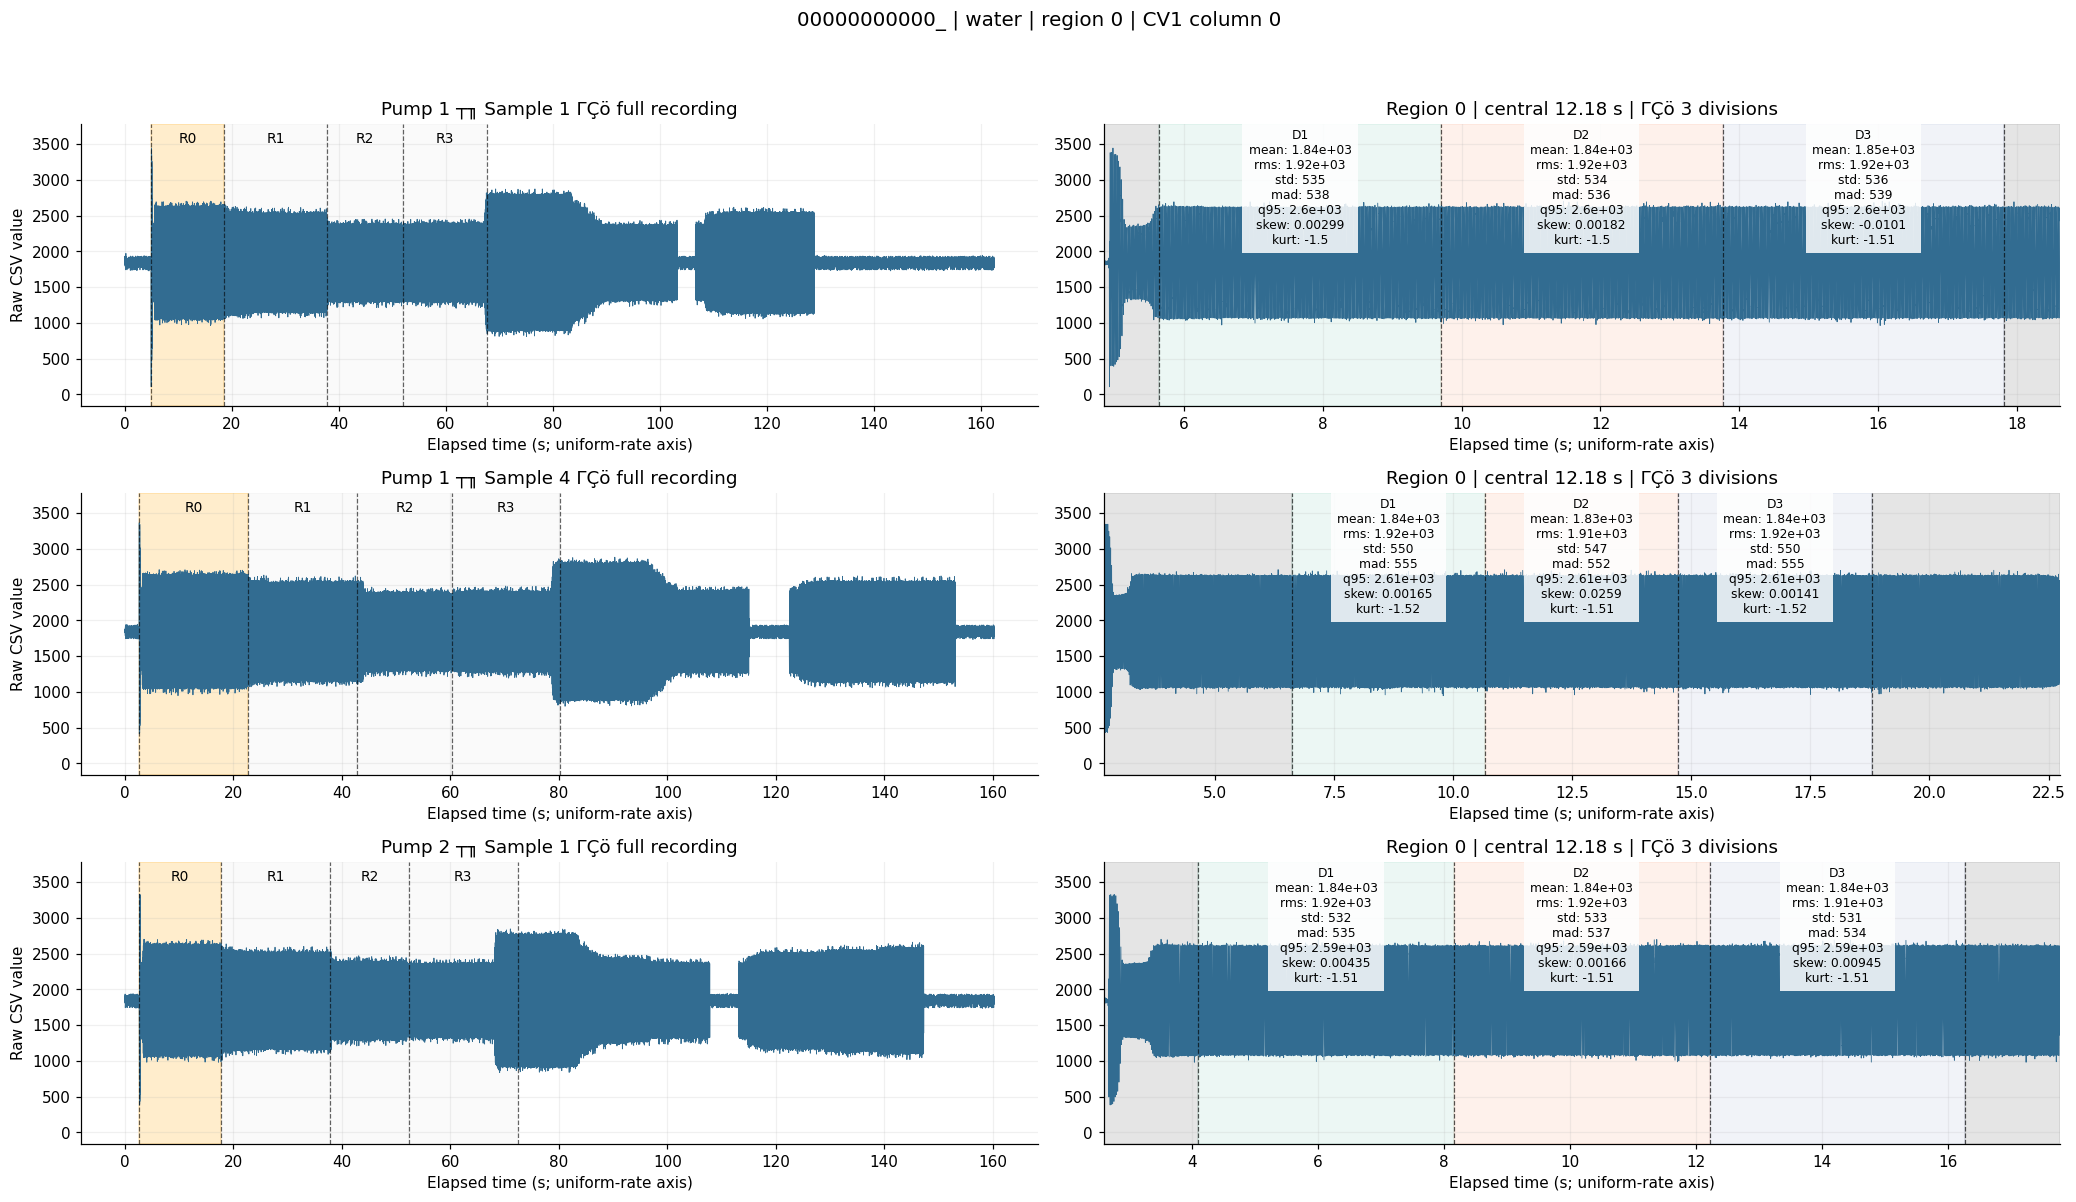

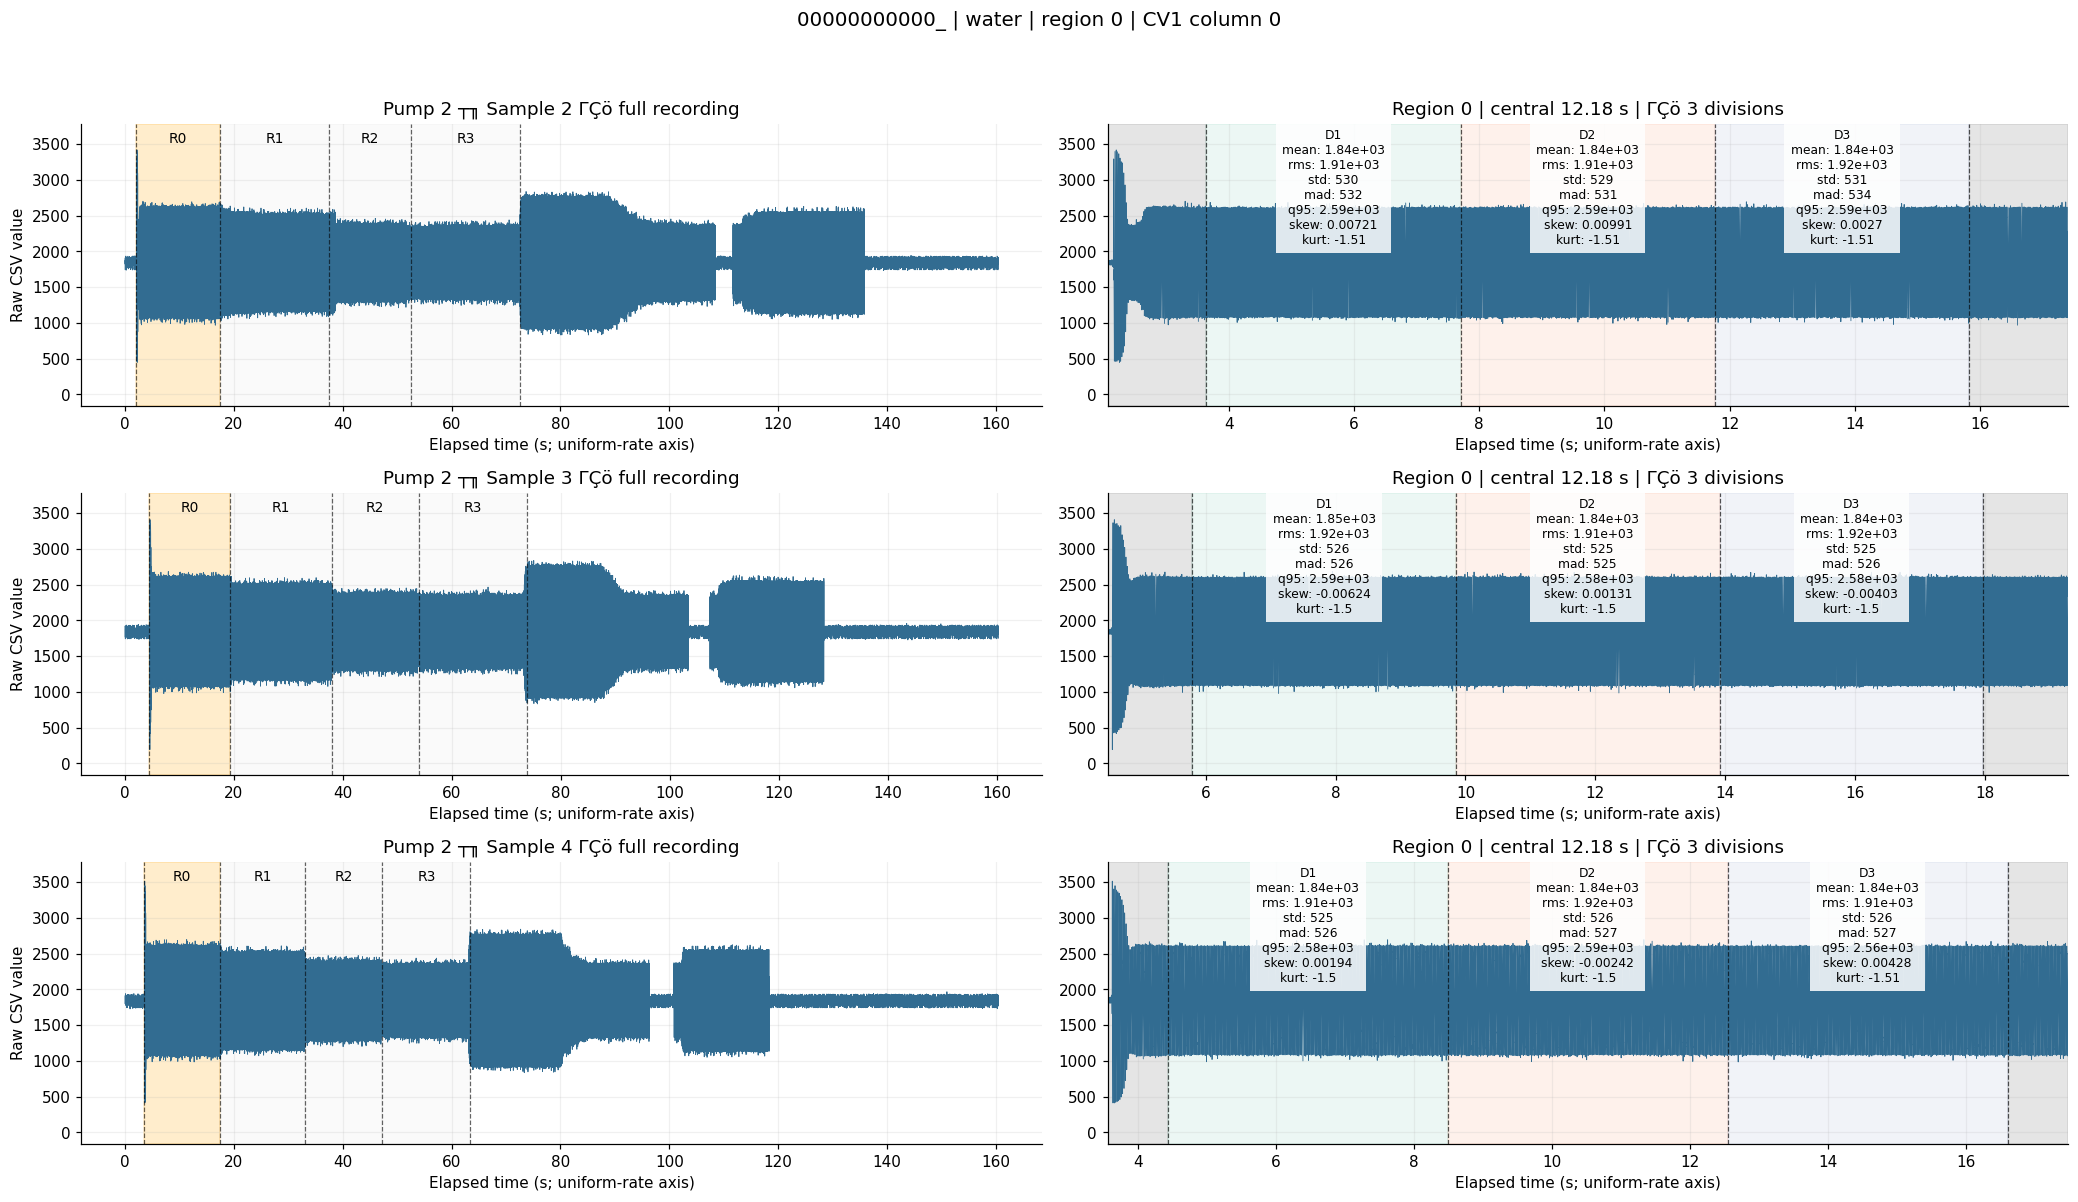

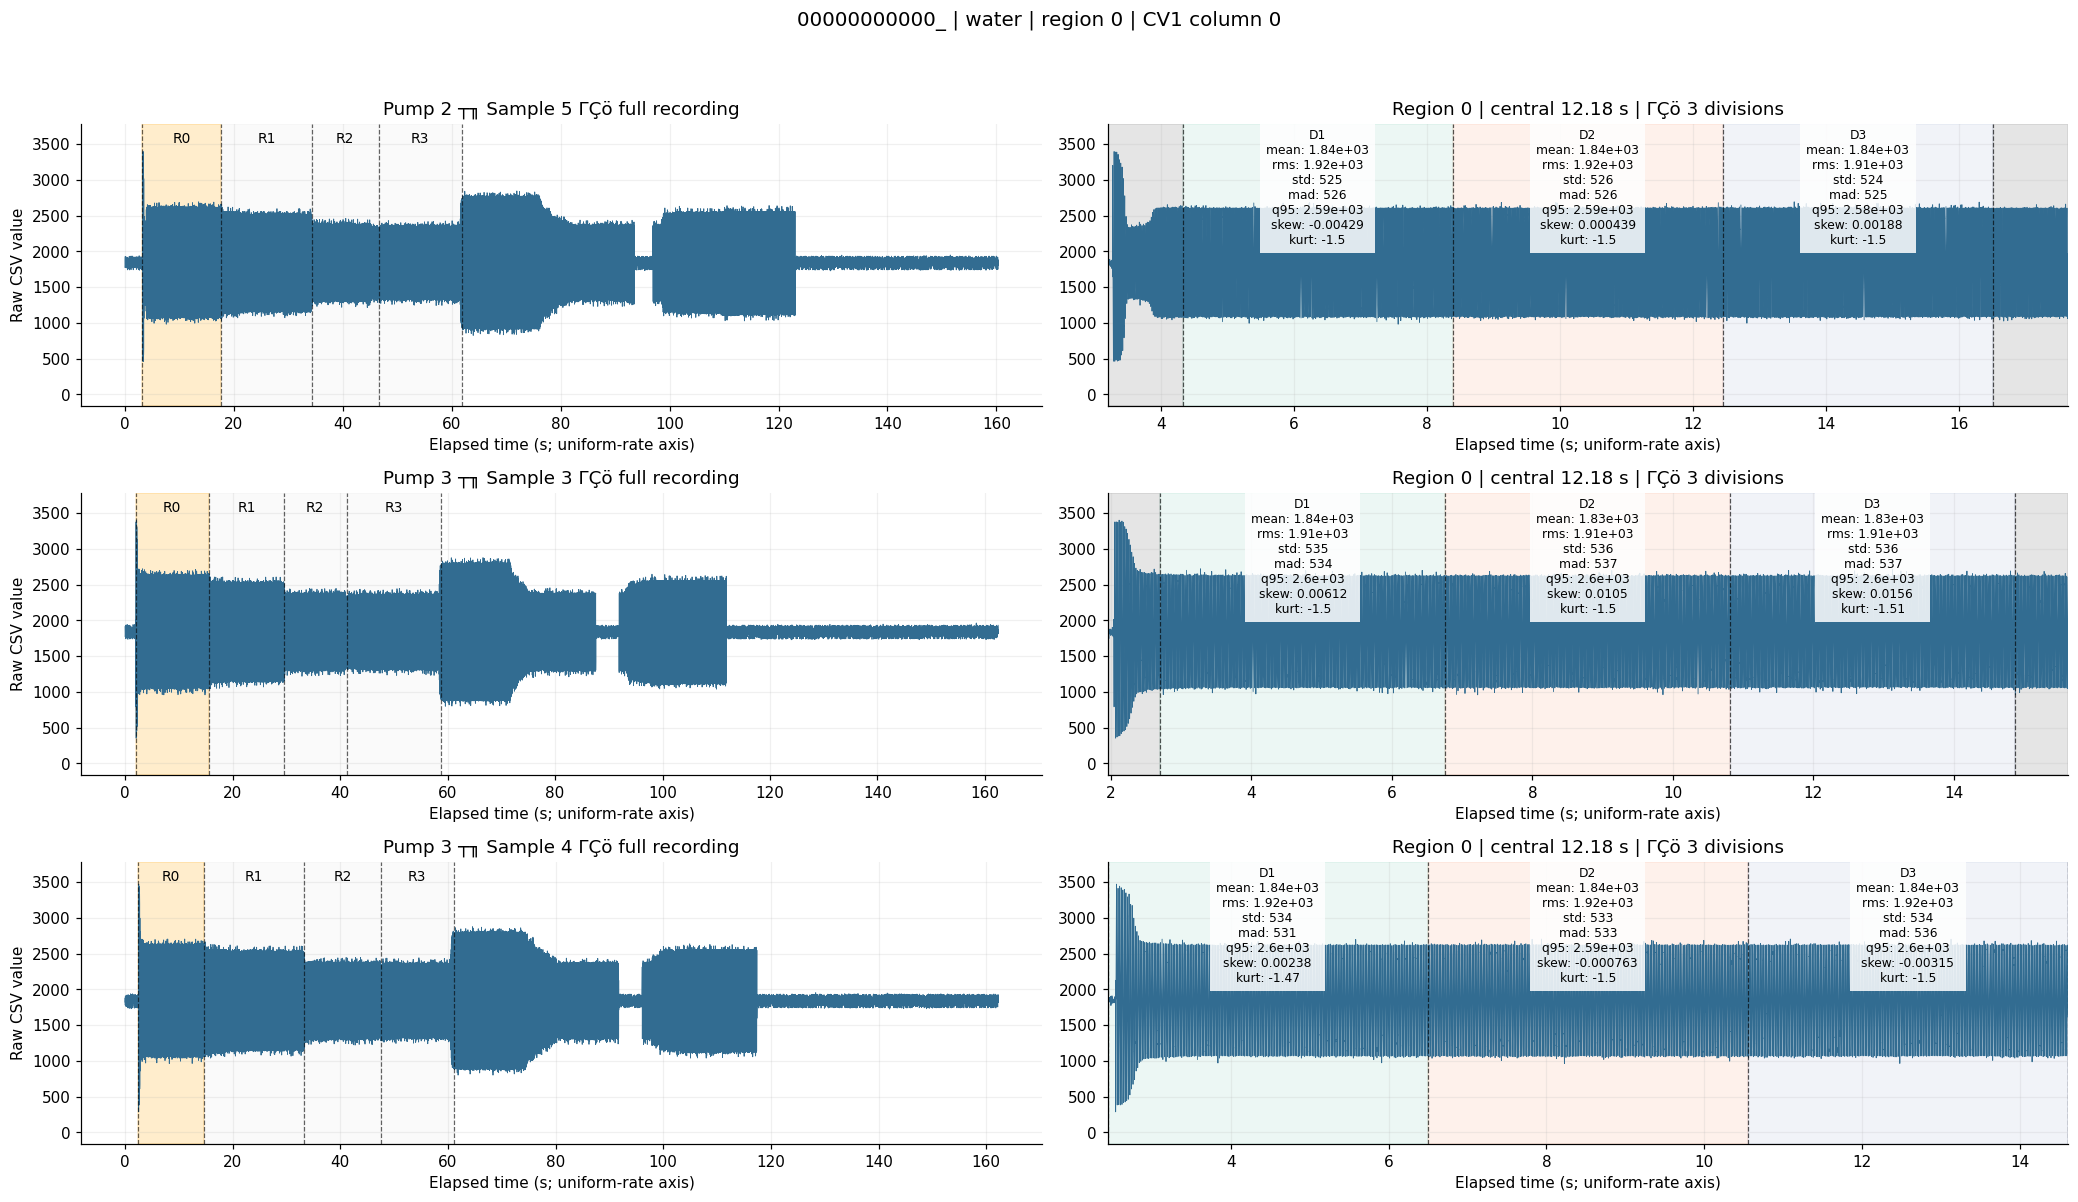

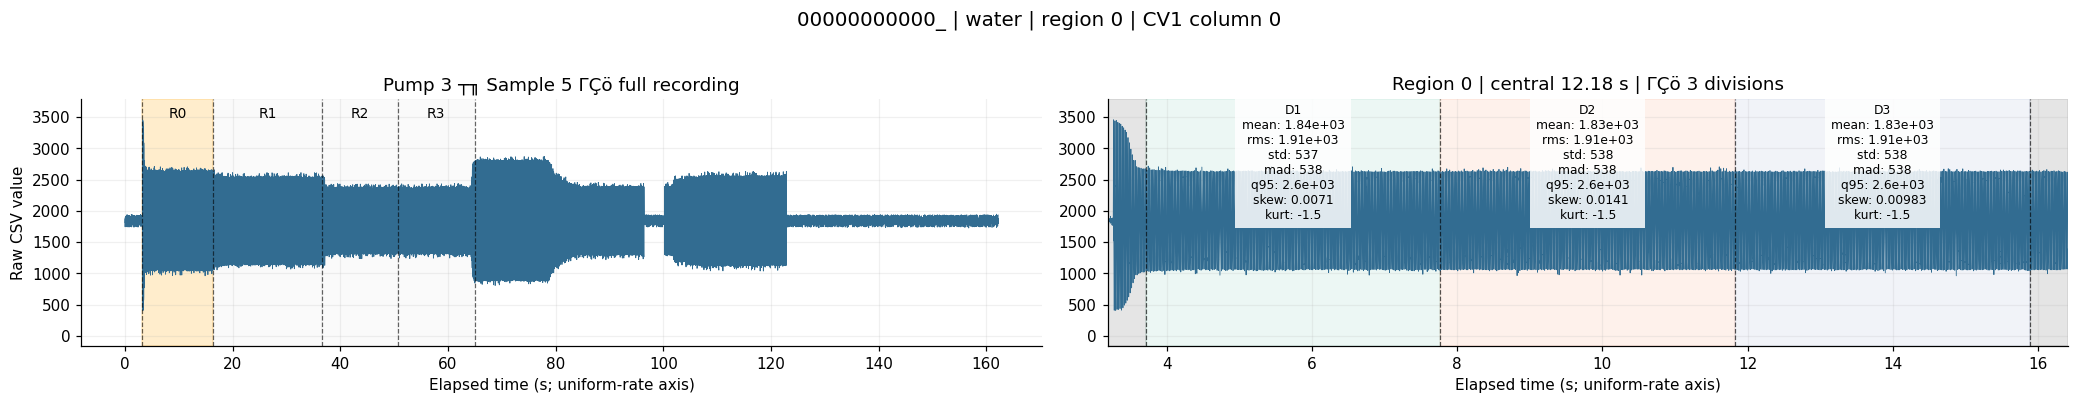

In [31]:
def plot_signal_regions(pump_id=None):
    items = [(key, view) for key, view in previews.items()
             if pump_id is None or key[0] == normalize_id(pump_id)]
    if not items:
        raise ValueError("No preview for this pump")
    finite_values = [v["full"][1][np.isfinite(v["full"][1])] for _, v in items]
    ymin = min(np.min(x) for x in finite_values if len(x))
    ymax = max(np.max(x) for x in finite_values if len(x))
    pad = max((ymax-ymin)*0.08, 1e-9)
    for page, start in enumerate(range(0, len(items), SAMPLES_PER_FIGURE), start=1):
        chunk = items[start:start + SAMPLES_PER_FIGURE]
        fig, axes = plt.subplots(len(chunk), 2, figsize=(19, 3.7*len(chunk)), squeeze=False)
        for (pump, sample), view, axrow in [(key, view, axrow) for (key, view), axrow in zip(chunk, axes)]:
            full, zoom = axrow
            full.plot(*view["full"], lw=0.55, color="#326c91")
            cp, bounds = view["cp_s"], view["division_s"]
            for j in range(len(cp)-1):
                full.axvspan(cp[j], cp[j+1], color="orange" if j==REGION else "grey",
                             alpha=0.20 if j==REGION else 0.04)
                full.text((cp[j]+cp[j+1])/2, 0.97, f"R{j}", ha="center", va="top",
                          transform=full.get_xaxis_transform(), fontsize=9)
            for x in cp:
                full.axvline(x, color="black", lw=0.8, ls="--", alpha=0.6)
            full.set(title=f"Pump {pump} ┬╖ Sample {sample} ΓÇö full recording",
                     xlabel="Elapsed time (s; uniform-rate axis)", ylabel="Raw CSV value")
            zoom.plot(*view["region"], lw=0.55, color="#326c91")
            zoom.axvspan(cp[REGION], bounds[0], color="grey", alpha=0.2)
            zoom.axvspan(bounds[-1], cp[REGION+1], color="grey", alpha=0.2)
            sample_features = feature_table[(feature_table.pump_id==pump) & (feature_table.sample_id==sample)]
            for d, (lo,hi) in enumerate(zip(bounds[:-1],bounds[1:]),start=1):
                zoom.axvspan(lo,hi,color=plt.cm.Set2((d-1)%8),alpha=0.12)
                vals=sample_features[sample_features.division==d].iloc[0]
                text=f"D{d}" + "\n".join([""] + [f"{f}: {vals[f]:.3g}" for f in FEATURES])
                zoom.text((lo+hi)/2,0.98,text,ha="center",va="top",fontsize=8,
                          transform=zoom.get_xaxis_transform(),
                          bbox={"facecolor":"white","alpha":0.85,"edgecolor":"none"})
            for x in bounds:
                zoom.axvline(x,color="black",lw=0.8,ls="--",alpha=0.65)
            zoom.set(title=f"Region {REGION} | central {common_duration_s:.4g} s | ΓÇö {N_DIVISIONS} divisions",
                     xlabel="Elapsed time (s; uniform-rate axis)", xlim=(cp[REGION],cp[REGION+1]))
            for ax in axrow:
                ax.set_ylim(ymin-pad,ymax+pad)
        fig.suptitle(selection_title,fontsize=13)
        finish_plot(fig,f"signals_pump_{pump_id or 'all'}_page_{page}")

plot_signal_regions()  # Or plot_signal_regions(pump_id=1)

In [32]:
feature_table

,fault_id,pump_id,sample_id,sample_id_key,state,signal,column,region,division,start_row,end_row_exclusive,start_s,end_s,duration_s,raw_samples,...,full_region_duration_s,common_duration_s,target_division_duration_s,window_start_s,window_end_s,actual_window_duration_s,reference_sample,mean,rms,std,mad,q95,skew,kurt,retained_samples
0,00000000000_,1,1,00000000000_@1@1,water,CV1,0,0,1,151883,261144,5.641925,9.700592,4.058666,109261,...,13.778091,12.176045,4.058682,5.641925,17.817961,12.176036,00000000000_@3@4@water,1838.904957,1915.066447,534.703708,538.0,2595.0,0.002992,-1.503923,103585
1,00000000000_,1,1,00000000000_@1@1,water,CV1,0,0,2,261144,370406,9.700592,13.759295,4.058703,109262,...,13.778091,12.176045,4.058682,5.641925,17.817961,12.176036,00000000000_@3@4@water,1839.747424,1915.671088,533.971100,536.0,2595.0,0.001818,-1.503372,103533
2,00000000000_,1,1,00000000000_@1@1,water,CV1,0,0,3,370406,479667,13.759295,17.817961,4.058666,109261,...,13.778091,12.176045,4.058682,5.641925,17.817961,12.176036,00000000000_@3@4@water,1846.657217,1922.981978,536.392405,539.0,2599.0,-0.010079,-1.507938,104267
3,00000000000_,1,4,00000000000_@1@4,water,CV1,0,0,1,178124,287538,6.607495,10.666198,4.058703,109414,...,20.087231,12.176045,4.058682,6.607495,18.783567,12.176072,00000000000_@3@4@water,1842.609628,1922.891260,549.818658,555.0,2611.0,0.001650,-1.515122,106273
4,00000000000_,1,4,00000000000_@1@4,water,CV1,0,0,2,287538,396951,10.666198,14.724864,4.058666,109413,...,20.087231,12.176045,4.058682,6.607495,18.783567,12.176072,00000000000_@3@4@water,1829.298395,1909.304879,546.911788,552.0,2607.0,0.025853,-1.511626,105434
5,00000000000_,1,4,00000000000_@1@4,water,CV1,0,0,3,396951,506365,14.724864,18.783567,4.058703,109414,...,20.087231,12.176045,4.058682,6.607495,18.783567,12.176072,00000000000_@3@4@water,1842.803993,1923.050938,549.725707,555.0,2611.0,0.001410,-1.516176,106445
6,00000000000_,2,1,00000000000_@2@1,water,CV1,0,0,1,110574,219955,4.102936,8.161605,4.058669,109381,...,15.178200,12.176045,4.058682,4.102936,16.278980,12.176044,00000000000_@3@4@water,1839.683511,1915.193984,532.477771,535.0,2591.0,0.004349,-1.507517,104841
7,00000000000_,2,1,00000000000_@2@1,water,CV1,0,0,2,219955,329337,8.161605,12.220311,4.058706,109382,...,15.178200,12.176045,4.058682,4.102936,16.278980,12.176044,00000000000_@3@4@water,1840.373772,1916.049596,533.170172,537.0,2591.0,0.001658,-1.511255,105337
8,00000000000_,2,1,00000000000_@2@1,water,CV1,0,0,3,329337,438718,12.220311,16.278980,4.058669,109381,...,15.178200,12.176045,4.058682,4.102936,16.278980,12.176044,00000000000_@3@4@water,1836.907145,1912.141061,531.089049,534.0,2590.0,0.009454,-1.507765,104335
9,00000000000_,2,2,00000000000_@2@2,water,CV1,0,0,1,98208,207504,3.646928,7.705605,4.058678,109296,...,15.332967,12.176045,4.058682,3.646928,15.822997,12.176070,00000000000_@3@4@water,1838.481433,1913.326392,529.909334,532.0,2589.1,0.007208,-1.509214,104619


## Middle-window and feature plotting helpers
Run these cells after the region feature calculation. All functions use current FAULT_ID, STATE, REGION, SIGNAL and COLUMN. For another signal/channel, change the settings and rerun the comparison first. `n_samples=None` uses a full division; an integer selects its middle rows (or all rows if shorter). Equal row counts do not imply equal seconds at different sample rates; use full divisions for the shared-duration comparison.

In [33]:
from scipy.signal import find_peaks, peak_widths, windows, butter, sosfiltfilt
from scipy.fft import rfft, rfftfreq
from scipy.stats import gmean, hmean, pmean, entropy


def _division_window(signal, pump_id, sample_id, division, n_samples=None):
    signal = str(signal).strip().upper()
    if signal != SIGNAL:
        raise ValueError(f"Set SIGNAL='{signal}', choose COLUMN, and rerun the comparison cells first.")
    pump_id, sample_id = normalize_id(pump_id), normalize_id(sample_id)
    if not isinstance(division, (int, np.integer)) or not 1 <= division <= N_DIVISIONS:
        raise ValueError(f"division must be 1..{N_DIVISIONS}")
    if n_samples is not None and (not isinstance(n_samples, (int, np.integer)) or n_samples < 4):
        raise ValueError("n_samples must be an integer >= 4, or None for the full division")
    rows = selected[(selected.pump_id == pump_id) & (selected.sample_id == sample_id)]
    if len(rows) != 1:
        raise ValueError("Pump/sample is not uniquely present in the current selection")
    values, fs, cp = load_signal(rows.iloc[0])
    bounds = division_bounds(cp, fs, common_duration_s)
    lo, hi = int(bounds[division-1]), int(bounds[division])
    count = hi-lo if n_samples is None else min(int(n_samples), hi-lo)
    start = lo + (hi-lo-count)//2
    x = values[start:start+count].copy()
    if len(x) < 4 or not np.isfinite(x).all():
        raise ValueError("Window is too short or contains NaN/Inf")
    info = {"signal": signal, "column": COLUMN, "pump_id": pump_id,
            "sample_id": sample_id, "division": int(division), "samples": count,
            "sampling_rate_hz": fs, "start_row": start, "end_row_exclusive": start+count,
            "duration_s": count/fs, "division_duration_s": (hi-lo)/fs,
            "common_duration_s": common_duration_s,
            "title": f"{FAULT_ID} | {STATE} R{REGION} D{division} | {signal}/{COLUMN} | P{pump_id} S{sample_id}",
            "name": f"{signal}_col{COLUMN}_pump{pump_id}_sample{sample_id}_d{division}_n{count}"}
    time_s = (np.arange(start, start+count) - (lo+hi-1)/2)/fs
    return x, fs, time_s, info


def _feature_display(features, info):
    print(f"{info['samples']} middle samples; duration={info['duration_s']:.6g} s; "
          f"fs={info['sampling_rate_hz']:.6g} Hz")
    table = pd.DataFrame({"feature": list(features), "value": list(features.values())})
    display(table)
    return table


def _fft_data(x, fs, window='hann', pad_factor=2):
    if window not in (None, 'hann', 'hamming'):
        raise ValueError("window must be None, 'hann', or 'hamming'")
    if not isinstance(pad_factor, int) or pad_factor < 1:
        raise ValueError("pad_factor must be a positive integer")
    y = x - np.mean(x)
    w = np.ones(len(y)) if window is None else windows.get_window(window, len(y), fftbins=False)
    freq = rfftfreq(len(y)*pad_factor, 1/fs)
    raw = np.abs(rfft(y*w, n=len(y)*pad_factor))
    amp = raw * (2/w.sum())
    amp[0] /= 2
    if (len(y)*pad_factor) % 2 == 0:
        amp[-1] /= 2
    return freq, raw, amp


def _freq_mask(freq, freq_range):
    lo, hi = (0.0, float(freq[-1])) if freq_range is None else map(float, freq_range)
    if not np.isfinite([lo, hi]).all() or lo < 0 or hi <= lo or hi > freq[-1]+1e-9:
        raise ValueError(f"Frequency limits must satisfy 0 <= low < high <= {freq[-1]:.6g} Hz")
    mask = (freq >= lo) & (freq <= hi)
    if mask.sum() < 3:
        raise ValueError("Too few FFT bins in this range; use a longer window or wider range")
    return mask

In [34]:
def small_signal_region(signal, pump_id, sample_id, division, feature='rms', n_samples=1000):
    feature = str(feature).lower()
    if feature not in FEATURES:
        raise ValueError(f"feature must be one of {FEATURES}")
    x, fs, t, info = _division_window(signal, pump_id, sample_id, division, n_samples)
    feats = common_features(x)
    fig, ax = plt.subplots(figsize=(12,4))
    ax.plot(t, x, lw=0.8)
    ax.axvline(0, color='black', ls='--', lw=0.8)
    ax.set(title=info['title'], xlabel='Time from division midpoint (s)', ylabel='Raw CSV value')
    ax.text(.98,.97, f"Middle {len(x)} samples\n{LABELS[feature]}: {feats[feature]:.6g}",
            transform=ax.transAxes, ha='right', va='top', bbox=dict(facecolor='white', alpha=.9))
    finish_plot(fig, 'middle_'+info['name'])
    return {"info": info, "features": feats}

# Example (use IDs that appear in selected):
# small_signal_region(SIGNAL, focus_pump, selected.iloc[0].sample_id, 1, n_samples=1000)

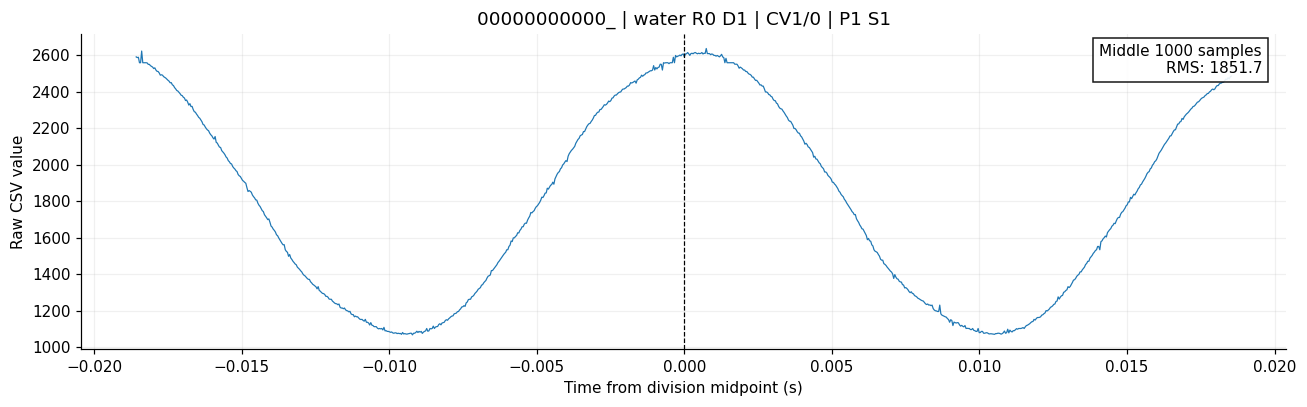

{'info': {'signal': 'CV1',
  'column': '0',
  'pump_id': '1',
  'sample_id': '1',
  'division': 1,
  'samples': 1000,
  'sampling_rate_hz': 26920.420143247436,
  'start_row': 206013,
  'end_row_exclusive': 207013,
  'duration_s': 0.03714652277634806,
  'division_duration_s': 4.058666225066565,
  'common_duration_s': 12.176044574181617,
  'title': '00000000000_ | water R0 D1 | CV1/0 | P1 S1',
  'name': 'CV1_col0_pump1_sample1_d1_n1000'},
 'features': {'mean': 1779.5575501583949,
  'rms': 1851.6991771508228,
  'std': 511.82493914939954,
  'mad': 497.0,
  'q95': 2551.0,
  'skew': 0.1115350430832484,
  'kurt': -1.459231911677465,
  'retained_samples': 947}}

In [35]:
small_signal_region(SIGNAL, focus_pump, selected.iloc[0].sample_id, 1, n_samples=1000)

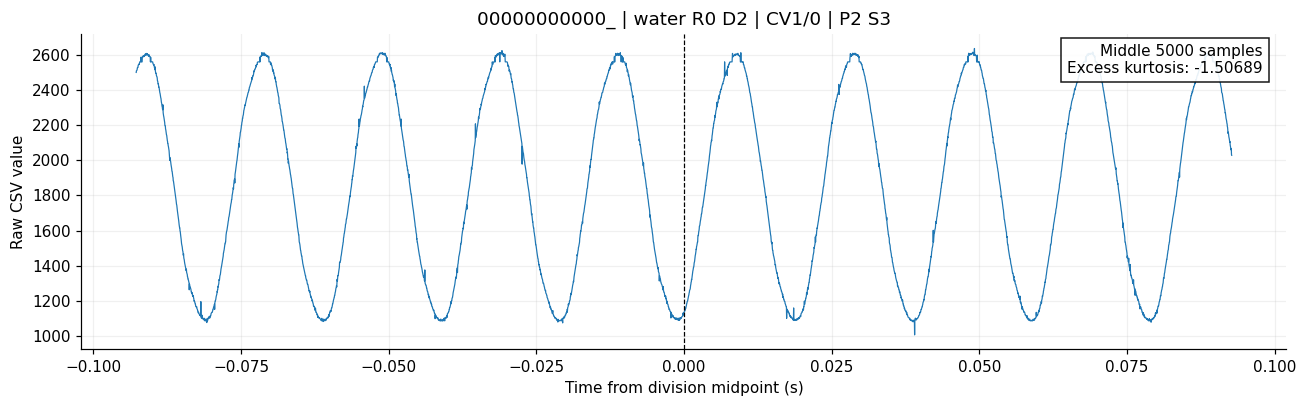

{'info': {'signal': 'CV1',
  'column': '0',
  'pump_id': '2',
  'sample_id': '3',
  'division': 2,
  'samples': 5000,
  'sampling_rate_hz': 26947.278137144214,
  'start_row': 317738,
  'end_row_exclusive': 322738,
  'duration_s': 0.1855474966545131,
  'division_duration_s': 4.058665941820819,
  'common_duration_s': 12.176044574181617,
  'title': '00000000000_ | water R0 D2 | CV1/0 | P2 S3',
  'name': 'CV1_col0_pump2_sample3_d2_n5000'},
 'features': {'mean': 1858.5062144512324,
  'rms': 1931.9902265038788,
  'std': 527.7697283405513,
  'mad': 528.0,
  'q95': 2585.7,
  'skew': -0.047231558983732665,
  'kurt': -1.5068868488920573,
  'retained_samples': 4747}}

In [36]:
small_signal_region(SIGNAL, 2, 3, 2,feature="kurt", n_samples=5000)

## 6. Within one pump: divisions compared across samples

One line per sample, x-axis = division number. Similar trajectories indicate repeatable within-region behaviour. A feature may legitimately change across divisions after an operating transition.

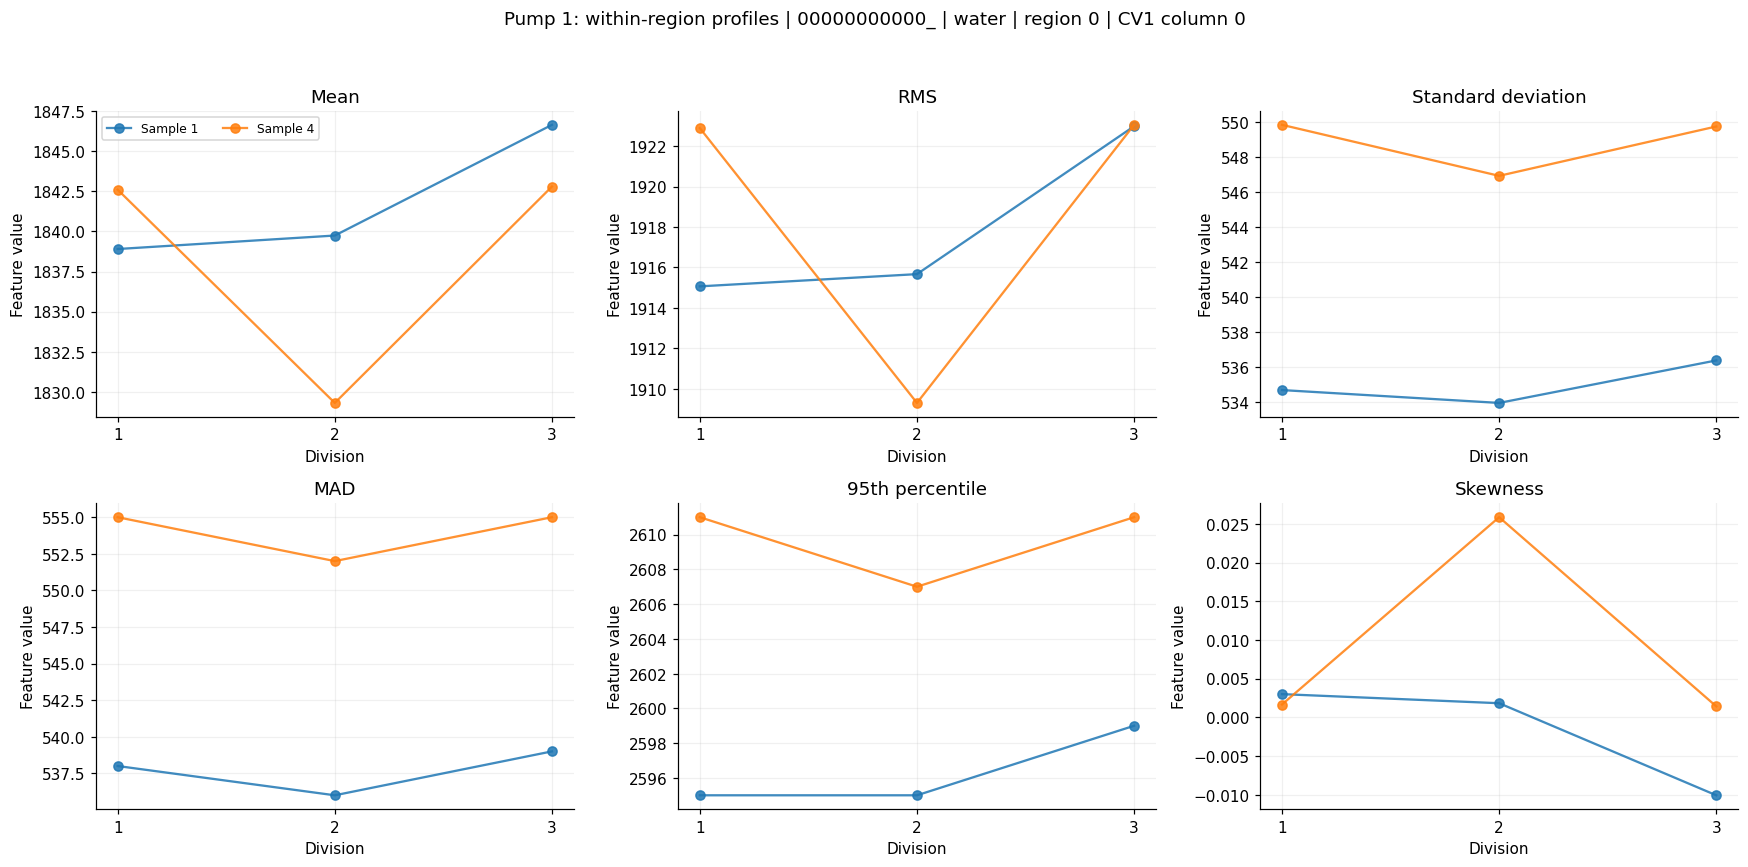

In [37]:
def plot_within_pump(pump_id):
    pump_id = normalize_id(pump_id)
    data = feature_table[feature_table.pump_id==pump_id]
    if data.empty:
        raise ValueError(f"No features for pump {pump_id}")
    samples = sorted(data.sample_id.unique(),key=int)
    fig, axes = plt.subplots(2,3,figsize=(16,8),squeeze=False)
    for ax, feature in zip(axes.flat,FEATURES):
        for sample in samples:
            values=data[data.sample_id==sample].sort_values("division")
            ax.plot(values.division,values[feature],marker="o",label=f"Sample {sample}",alpha=0.85)
        ax.set(title=LABELS[feature],xlabel="Division",xticks=range(1,N_DIVISIONS+1),ylabel="Feature value")
    axes[0,0].legend(fontsize=8,ncol=2)
    fig.suptitle(f"Pump {pump_id}: within-region profiles | {selection_title}")
    finish_plot(fig,f"within_pump_{pump_id}_division_profiles")

plot_within_pump(focus_pump)

## 7. Within one pump: compare samples at a fixed division

One line per division; x-axis = sample ID (categorical, not elapsed time). Compare values along the same coloured line to judge sample-to-sample repeatability at that region position.

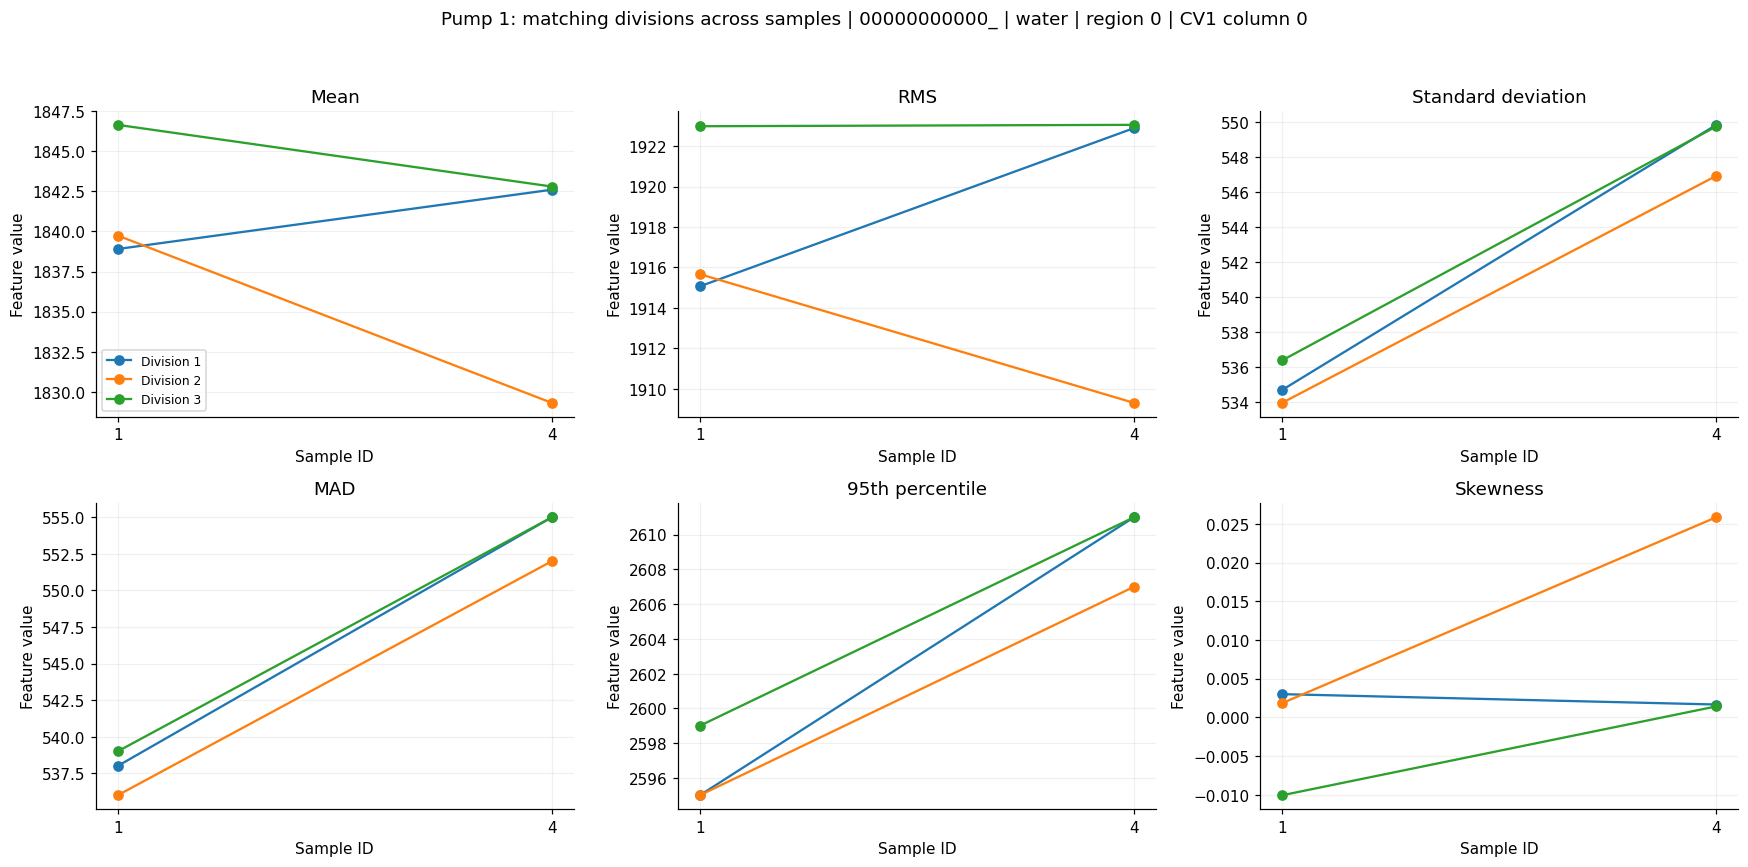

In [38]:
def plot_samples_at_divisions(pump_id):
    pump_id=normalize_id(pump_id)
    data=feature_table[feature_table.pump_id==pump_id]
    if data.empty:
        raise ValueError(f"No features for pump {pump_id}")
    samples=sorted(data.sample_id.unique(),key=int)
    fig,axes=plt.subplots(2,3,figsize=(16,8))
    for ax,feature in zip(axes.flat,FEATURES):
        for division in range(1,N_DIVISIONS+1):
            values=data[data.division==division].set_index("sample_id").reindex(samples)
            ax.plot(range(len(samples)),values[feature],marker="o",label=f"Division {division}")
        ax.set(title=LABELS[feature],xlabel="Sample ID",ylabel="Feature value",
               xticks=range(len(samples)),xticklabels=samples)
    axes[0,0].legend(fontsize=8)
    fig.suptitle(f"Pump {pump_id}: matching divisions across samples | {selection_title}")
    finish_plot(fig,f"within_pump_{pump_id}_samples")

plot_samples_at_divisions(focus_pump)

## 8. Between pumps: compare the same region and division

Small dots are individual samples; large markers are per-pump means, with ┬▒1 sample SD error bars. Colours identify matching divisions. Means give each sample equal weight regardless of the region's duration. A single sample has no estimable SD, so its error bar is omitted. Different pump means can reflect physical variability, calibration, acquisition settings or alignmentΓÇönot necessarily a different fault.

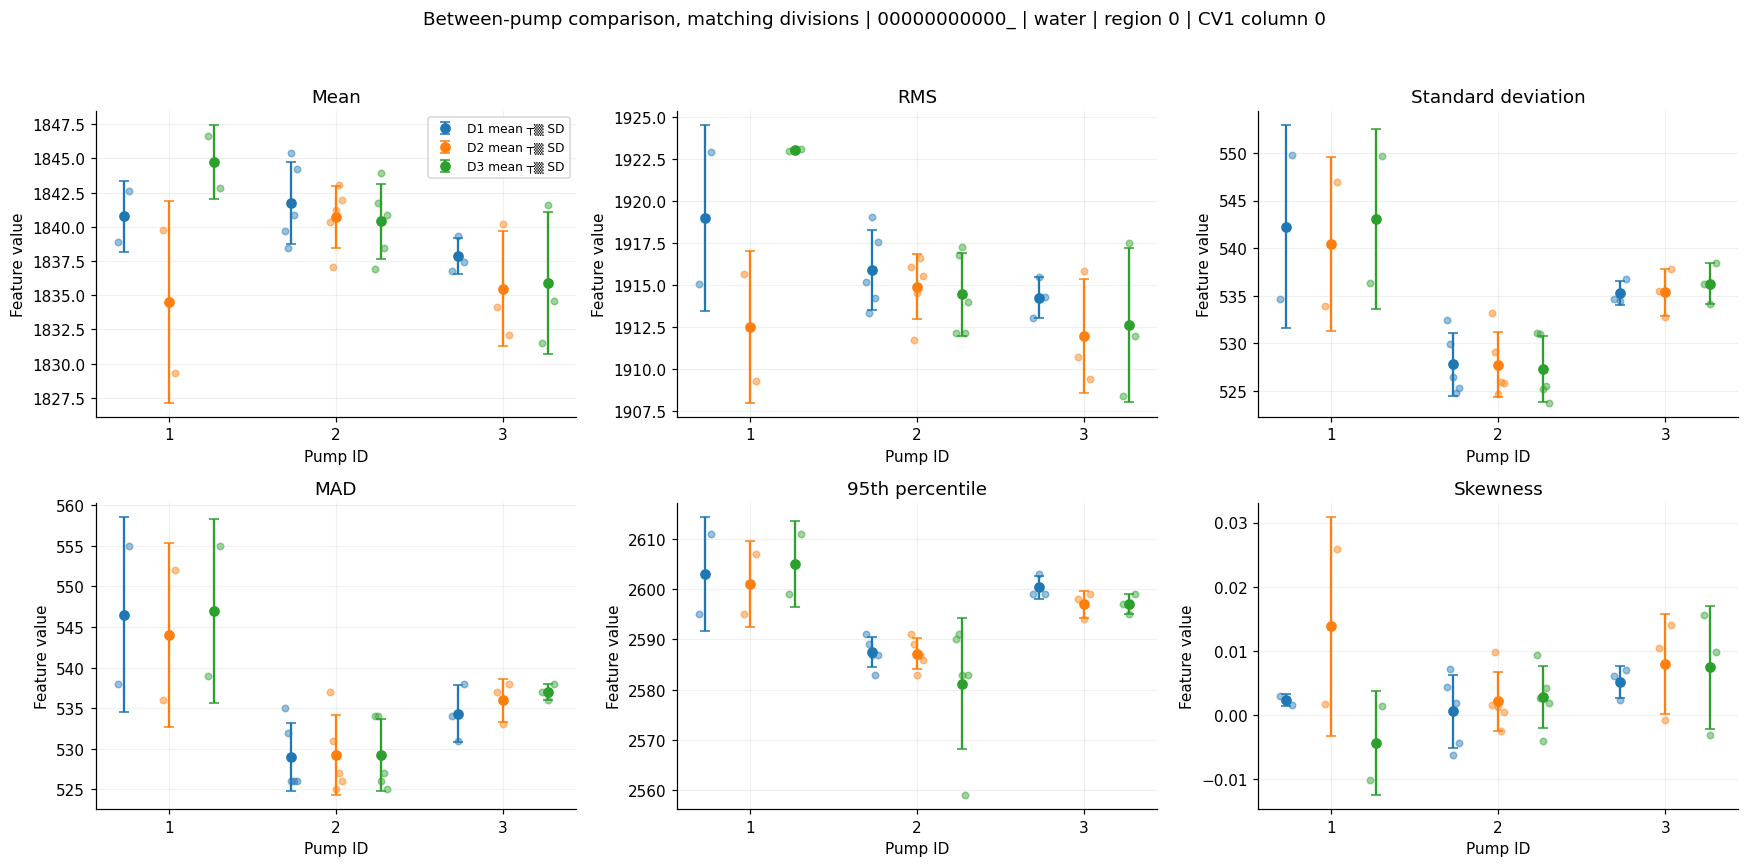

,pump_id,division,feature,n,mean,sd,minimum,maximum,range,cv_pct
0,1,1,kurt,2,-1.50952,0.00792,-1.51512,-1.50392,0.01120,NaN
1,1,1,mad,2,546.50000,12.02082,538.00000,555.00000,17.00000,2.19960
2,1,1,mean,2,1840.75729,2.61960,1838.90496,1842.60963,3.70467,NaN
3,1,1,q95,2,2603.00000,11.31371,2595.00000,2611.00000,16.00000,NaN
4,1,1,rms,2,1918.97885,5.53298,1915.06645,1922.89126,7.82481,0.28833
...,...,...,...,...,...,...,...,...,...,...
58,3,3,mean,3,1835.89146,5.18914,1831.49444,1841.61514,10.12070,NaN
59,3,3,q95,3,2597.00000,2.00000,2595.00000,2599.00000,4.00000,NaN
60,3,3,rms,3,1912.61853,4.59637,1908.39557,1917.51417,9.11860,0.24032
61,3,3,skew,3,0.00744,0.00962,-0.00315,0.01564,0.01880,NaN


In [39]:
long_features = feature_table.melt(
    id_vars=["fault_id","state","region","pump_id","sample_id","division"],
    value_vars=FEATURES,var_name="feature",value_name="value")
pump_summary = long_features.groupby(["pump_id","division","feature"]).value.agg(
    n="count",mean="mean",sd="std",minimum="min",maximum="max").reset_index()
pump_summary["range"] = pump_summary.maximum-pump_summary.minimum
# Relative SD is intentionally restricted to nonnegative scale features.
# It is not interpretable for near-zero signed skewness/kurtosis.
pump_summary["cv_pct"] = np.nan
mask=pump_summary.feature.isin(["rms","std","mad"]) & (pump_summary["mean"].abs()>1e-12)
pump_summary.loc[mask,"cv_pct"] = 100*pump_summary.loc[mask,"sd"]/pump_summary.loc[mask,"mean"].abs()

def plot_between_pumps():
    pumps=sorted(feature_table.pump_id.unique(),key=int)
    offsets=np.linspace(-0.27,0.27,N_DIVISIONS) if N_DIVISIONS>1 else [0.0]
    fig,axes=plt.subplots(2,3,figsize=(16,8))
    for ax,feature in zip(axes.flat,FEATURES):
        for division,offset in enumerate(offsets,start=1):
            color=plt.cm.tab10((division-1)%10)
            for pos,pump in enumerate(pumps):
                values=feature_table[(feature_table.pump_id==pump)&(feature_table.division==division)][feature]
                jitter=np.linspace(-0.035,0.035,len(values)) if len(values)>1 else np.array([0.0])
                ax.scatter(pos+offset+jitter,values,color=color,s=18,alpha=0.45)
                mean=float(values.mean()); sd=float(values.std(ddof=1))
                ax.errorbar(pos+offset,mean,yerr=sd if np.isfinite(sd) else None,
                            fmt="o",color=color,markersize=6,capsize=3,
                            label=f"D{division} mean ┬▒ SD" if pos==0 else None)
        ax.set(title=LABELS[feature],xlabel="Pump ID",ylabel="Feature value",
               xticks=range(len(pumps)),xticklabels=pumps)
    axes[0,0].legend(fontsize=8)
    fig.suptitle(f"Between-pump comparison, matching divisions | {selection_title}")
    finish_plot(fig,"between_pumps")

plot_between_pumps()
display(pump_summary.round(5))

## 9. Feature heatmaps: every sample ├ù division

Each heatmap uses its own feature's raw numerical scale. Rows are labelled pump/sample and separated by pump; columns are divisions of the selected region. Similar colours within one column indicate similar values at the same region position. Colours are not comparable between different feature panels.

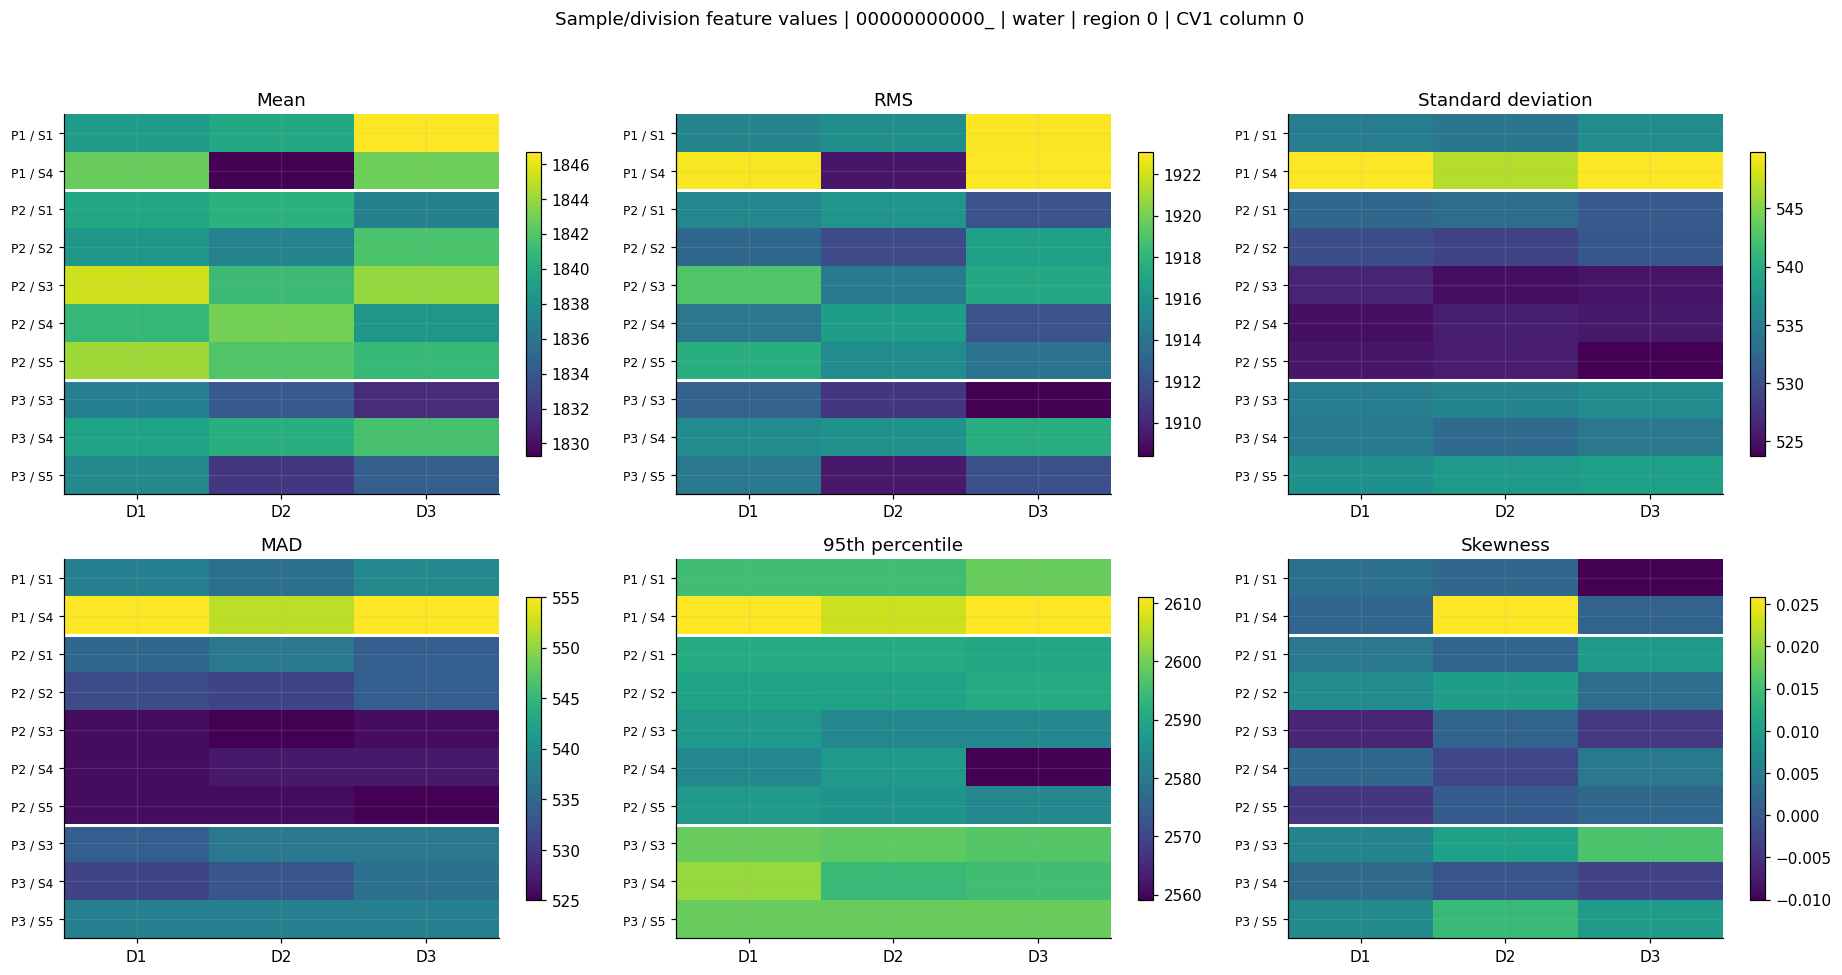

In [40]:
def plot_feature_heatmaps():
    row_order=list(selected[["pump_id","sample_id"]].itertuples(index=False,name=None))
    fig,axes=plt.subplots(2,3,figsize=(17,max(9,0.36*len(row_order))))
    for ax,feature in zip(axes.flat,FEATURES):
        matrix=feature_table.pivot(index=["pump_id","sample_id"],columns="division",values=feature)
        matrix=matrix.reindex(index=pd.MultiIndex.from_tuples(row_order,names=["pump_id","sample_id"]),
                              columns=range(1,N_DIVISIONS+1))
        image=ax.imshow(matrix.to_numpy(),aspect="auto",cmap="viridis")
        ax.set(title=LABELS[feature],xticks=range(N_DIVISIONS),
               xticklabels=[f"D{i}" for i in range(1,N_DIVISIONS+1)],
               yticks=range(len(row_order)),yticklabels=[f"P{p} / S{s}" for p,s in row_order])
        ax.tick_params(axis="y",labelsize=8)
        for i in range(1,len(row_order)):
            if row_order[i][0]!=row_order[i-1][0]:
                ax.axhline(i-0.5,color="white",lw=2)
        fig.colorbar(image,ax=ax,shrink=0.8)
    fig.suptitle(f"Sample/division feature values | {selection_title}")
    finish_plot(fig,"feature_heatmaps")

plot_feature_heatmaps()

## 10. Quantify three different sources of variation

- **Within a sample, across divisions:** highlights transitions or drift. This is descriptive variation over a trajectory, not repeated-measure noise.
- **Within a pump, across samples at the same division:** sample-to-sample repeatability (`pump_summary` above).
- **Between pump means at the same division:** physical-pump differences. `pooled_within_pump_sd` pools sample variances using sample degrees of freedom; `between_pump_sd` is the SD of pump means with equal weight per pump. Their ratio is descriptive, not a significance test or pure variance-component estimate. Undefined ratios remain NaN.

There is no automatic pass/fail threshold: practical tolerances must reflect the sensor's units and expected operating variation. Higher variation between pumps than within a pump can explain why unknown-pump classification is harder.

,pump_id,sample_id,feature,divisions,mean,sd_across_divisions,minimum,maximum,range_across_divisions
0,1,1,kurt,3,-1.50508,0.00249,-1.50794,-1.50337,0.00457
1,1,1,mad,3,537.66667,1.52753,536.00000,539.00000,3.00000
2,1,1,mean,3,1841.76987,4.25348,1838.90496,1846.65722,7.75226
3,1,1,q95,3,2596.33333,2.30940,2595.00000,2599.00000,4.00000
4,1,1,rms,3,1917.90650,4.40587,1915.06645,1922.98198,7.91553
...,...,...,...,...,...,...,...,...,...
65,3,5,mean,3,1834.70056,2.68408,1832.08694,1837.44994,5.36300
66,3,5,q95,3,2599.00000,0.00000,2599.00000,2599.00000,0.00000
67,3,5,rms,3,1911.86121,2.43533,1909.38466,1914.25311,4.86846
68,3,5,skew,3,0.01035,0.00353,0.00710,0.01411,0.00700


,division,feature,pumps,pump_mean_min,pump_mean_max,pooled_within_pump_sd,between_pump_sd,between_to_within_sd_ratio,between_pump_cv_pct
0,1,kurt,3,-1.50952,-1.49092,0.01006,0.00963,0.95665,NaN
1,1,mad,3,529.00000,546.50000,5.86962,8.96960,1.52814,1.67153
2,1,mean,3,1837.86274,1841.73186,2.55745,2.01239,0.78687,NaN
3,1,q95,3,2587.42000,2603.00000,4.98848,8.33268,1.67038,NaN
4,1,rms,3,1914.23669,1918.97885,2.83753,2.40915,0.84903,0.12571
5,1,skew,3,0.00059,0.00520,0.00453,0.00233,0.51424,NaN
6,1,std,3,527.79369,542.26118,4.79356,7.23564,1.50945,1.35215
7,2,kurt,3,-1.50750,-1.50168,0.00410,0.00292,0.71117,NaN
8,2,mad,3,529.20000,544.00000,5.84074,7.40810,1.26835,1.38108
9,2,mean,3,1834.52291,1840.71937,3.97902,3.33409,0.83792,NaN


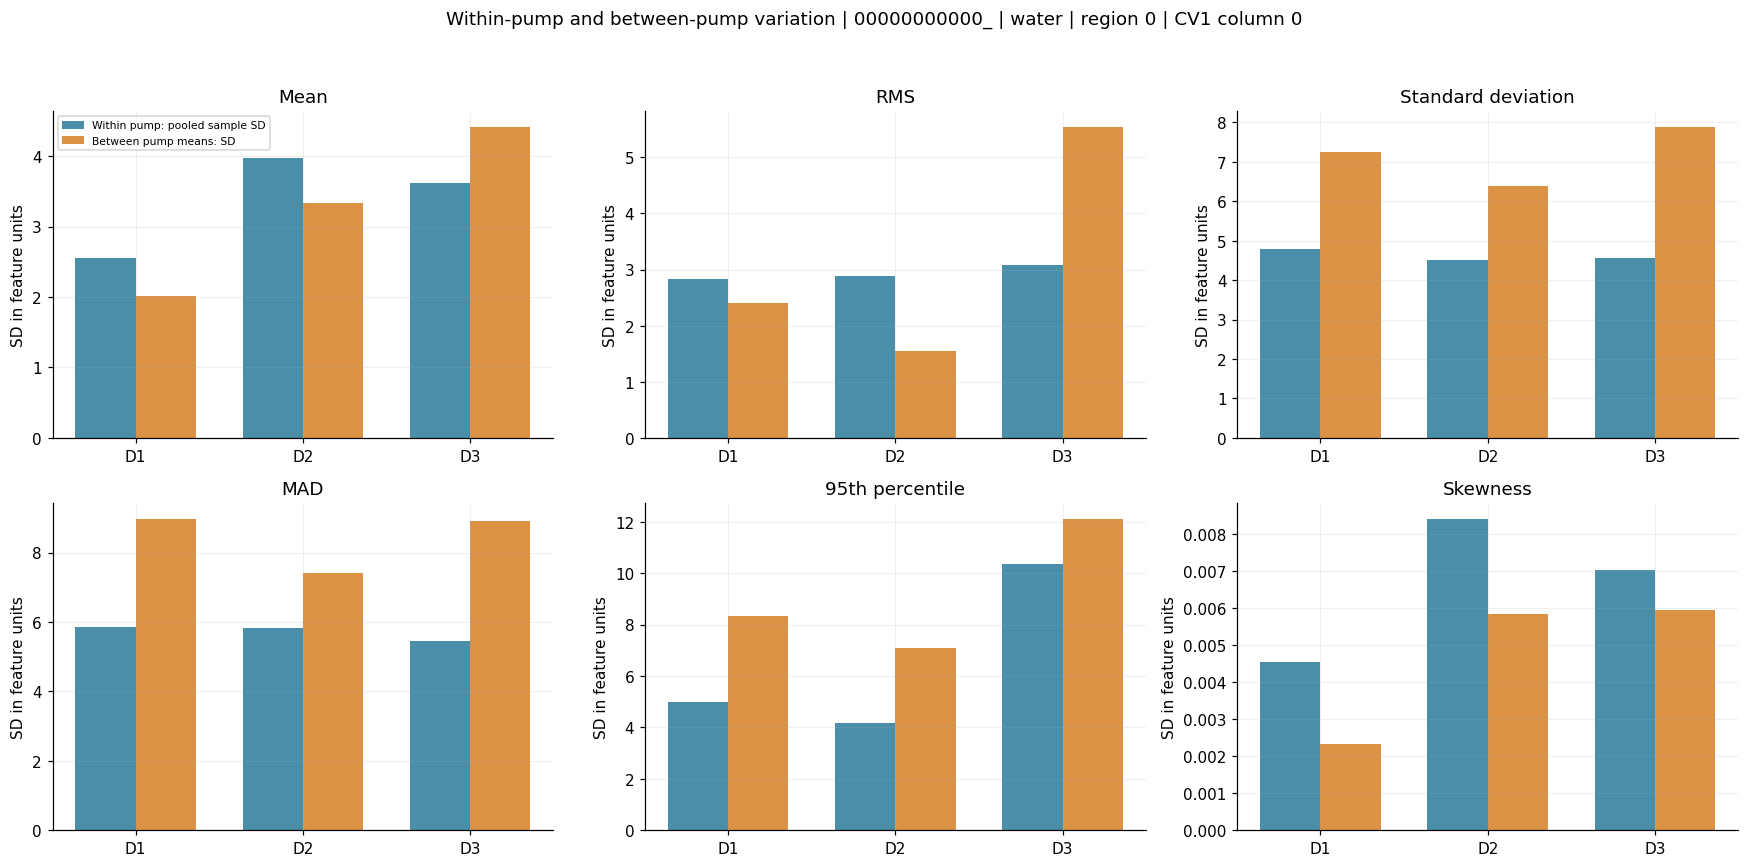

In [41]:
within_sample = long_features.groupby(["pump_id","sample_id","feature"]).value.agg(
    divisions="count",mean="mean",sd_across_divisions="std",minimum="min",maximum="max").reset_index()
within_sample["range_across_divisions"] = within_sample.maximum-within_sample.minimum

variation_rows=[]
for (division,feature), group in pump_summary.groupby(["division","feature"]):
    dof=(group.n-1).clip(lower=0)
    denominator=float(dof.sum())
    pooled=np.sqrt(float(((dof*group.sd**2).fillna(0)).sum())/denominator) if denominator>0 else np.nan
    between=float(group["mean"].std(ddof=1))
    grand=float(group["mean"].mean())
    variation_rows.append({"division":division,"feature":feature,"pumps":len(group),
        "pump_mean_min":float(group["mean"].min()),"pump_mean_max":float(group["mean"].max()),
        "pooled_within_pump_sd":pooled,"between_pump_sd":between,
        "between_to_within_sd_ratio":between/pooled if np.isfinite(pooled) and pooled>1e-12 else np.nan,
        "between_pump_cv_pct":100*between/abs(grand)
            if feature in ["rms","std","mad"] and abs(grand)>1e-12 else np.nan})
variation_summary=pd.DataFrame(variation_rows)
display(within_sample.round(5))
display(variation_summary.round(5))

fig,axes=plt.subplots(2,3,figsize=(16,8))
for ax,feature in zip(axes.flat,FEATURES):
    data=variation_summary[variation_summary.feature==feature].sort_values("division")
    x=np.arange(len(data))
    ax.bar(x-0.18,data.pooled_within_pump_sd,width=0.36,label="Within pump: pooled sample SD",color="#4a8eaa")
    ax.bar(x+0.18,data.between_pump_sd,width=0.36,label="Between pump means: SD",color="#dc9245")
    ax.set(title=LABELS[feature],xticks=x,xticklabels=[f"D{i}" for i in data.division],ylabel="SD in feature units")
axes[0,0].legend(fontsize=7)
fig.suptitle(f"Within-pump and between-pump variation | {selection_title}")
finish_plot(fig,"variation_summary")

## 11. Optional exports and changing the selection

Set `EXPORT_TABLES=True` to write the diagnostic tables and settings here. Set `SAVE_PLOTS=True` before running plotting cells to save their PNGs. Outputs go to a separate comparison directory; rerunning the same selection replaces only its diagnostic outputs. No training feature files are overwritten.

For another fault/state/region, edit the selection cell and rerun from the inventory cell. For another already-loaded pump, run `plot_within_pump(2)`, `plot_samples_at_divisions(2)` or `plot_signal_regions(2)`. For another signal/channel, change `SIGNAL` / `COLUMN` and reload.

In [42]:
if EXPORT_TABLES:
    import json
    output_dir.mkdir(parents=True,exist_ok=True)
    for name,table in [("region_durations_all_samples",region_duration_table), ("division_features",feature_table),("within_pump_sample_variation",pump_summary),
                       ("within_sample_division_variation",within_sample),("between_pump_variation",variation_summary)]:
        table.to_csv(output_dir/f"{name}.csv",index=False)
    settings={"fault_id":FAULT_ID,"state":STATE,"region":REGION,"signal":SIGNAL,"column":COLUMN,
              "common_duration_s":common_duration_s,"reference_sample":reference_sample,
              "minimum_scope":"all pumps/samples for selected fault/state/region/signal",
              "divisions":N_DIVISIONS,"edge_seconds":REGION_EDGE_SECONDS,"trim_quantiles":TRIM_QUANTILES,
              "features":FEATURES,"sample_keys":selected.sample_id_key.tolist(),
              "metadata_path":str(META_PATH),"timestamps_path":str(TIMESTAMPS_PATH)}
    (output_dir/"comparison_settings.json").write_text(json.dumps(settings,indent=2))
    print("Saved diagnostic tables:",output_dir.resolve())
else:
    print("Display-only mode: no diagnostic tables written.")

Display-only mode: no diagnostic tables written.


## Additional feature diagnostics — FFT, analog, physics and digital
Each function is in its own cell; example calls are commented out so Run All does not assume particular pump IDs. Returned dictionaries contain feature tables and window metadata.

These adapt the supplied FAN reference feature families to PUMP's equal-duration division windows. They are diagnostics, not exact replacements for training features (window position/length and some preprocessing differ). FFT uses every row in the chosen window; no quantile deletion is applied because it breaks time spacing. Zero padding refines plotted bins, not physical frequency resolution. Features retain raw CSV units.

Analog: dominant peak, peak width at 85% prominence, FFT distribution statistics, centroid, bandwidth and entropy. Raw FFT magnitude depends on window length. No detected peak is reported as NaN.

Physics: paired peak/trough amplitudes, AC RMS, crest factor and within-window settling. Peaks are paired with the following trough before the next peak, unlike the reference's independent list pairing. Pair count is not mechanical revolutions. Settling is relative to this window, not motor startup; no stable run gives NaN. RPM coast-down features require an RPM channel and a stop-aligned interval and are not inferred from AC1/GYR.

Digital: reference FFT statistics, band powers/peaks/ranks and optional CWT, time/frequency contrast and spike features. Wavelet mean/std spike intervals follow the reference in samples. Default bands are reference settings, not calibrated PUMP fault bands; change them as needed. `filter_band=None` skips bandpass but removes DC. Optional CWT needs `PyWavelets`, is bounded in size, and never downsamples automatically. Uncovered wavelet bands give NaN.

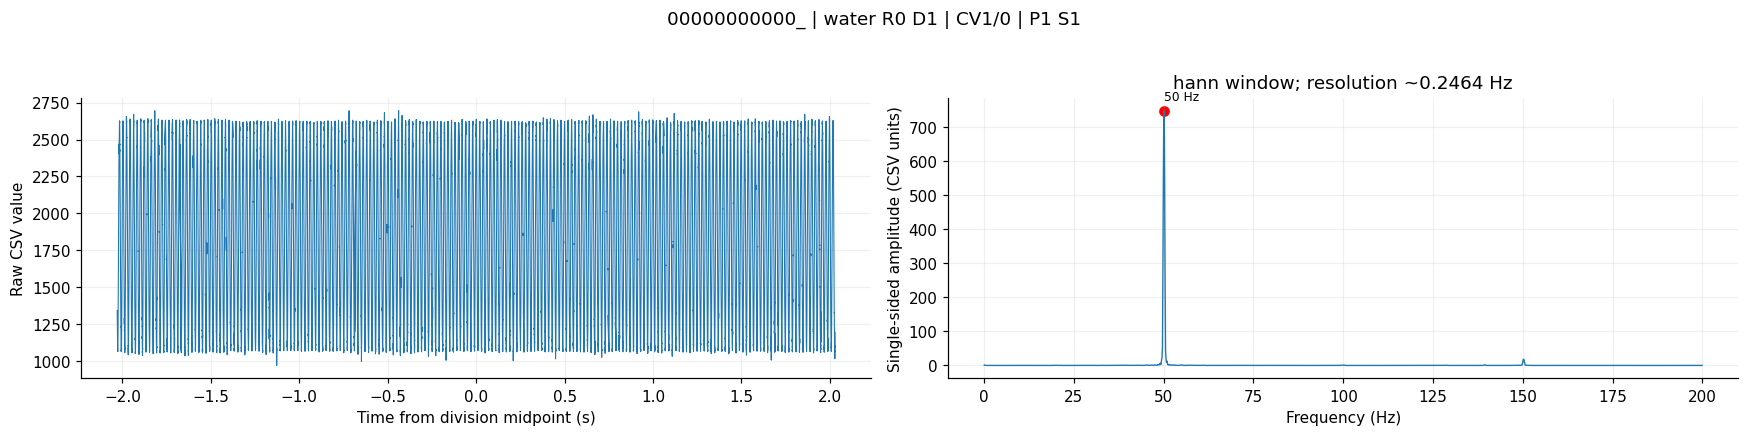

In [43]:
def plot_division_fft(signal, pump_id, sample_id, division, n_samples=None,
                      freq_range=(0,200), window='hann', top_n=5):
    """DC-removed FFT; n_samples=None uses the full division."""
    if not isinstance(top_n, int) or top_n < 1:
        raise ValueError("top_n must be a positive integer")
    x, fs, t, info = _division_window(signal, pump_id, sample_id, division, n_samples)
    freq, raw, amp = _fft_data(x, fs, window)
    mask = _freq_mask(freq, freq_range)
    f, a = freq[mask], amp[mask]
    peaks, _ = find_peaks(a, height=a.max()*.1)
    peaks = peaks[np.argsort(a[peaks])[::-1][:top_n]]
    fig, axes = plt.subplots(1,2,figsize=(16,4))
    axes[0].plot(t, x, lw=.7)
    axes[0].set(xlabel='Time from division midpoint (s)', ylabel='Raw CSV value')
    axes[1].plot(f,a,lw=.9)
    axes[1].scatter(f[peaks],a[peaks],c='red')
    for k in peaks:
        axes[1].annotate(f'{f[k]:.3g} Hz', (f[k],a[k]), xytext=(0,7),
                         textcoords='offset points', fontsize=8)
    axes[1].set(xlabel='Frequency (Hz)', ylabel='Single-sided amplitude (CSV units)',
                title=f'{window or "Rectangular"} window; resolution ~{fs/len(x):.4g} Hz')
    fig.suptitle(info['title'])
    finish_plot(fig,'fft_'+info['name'])
    return {"info":info, "spectrum":pd.DataFrame({"frequency_hz":freq,"amplitude":amp}),
            "peaks":pd.DataFrame({"frequency_hz":f[peaks],"amplitude":a[peaks]})}

result = plot_division_fft(SIGNAL, focus_pump, selected.iloc[0].sample_id, 1)

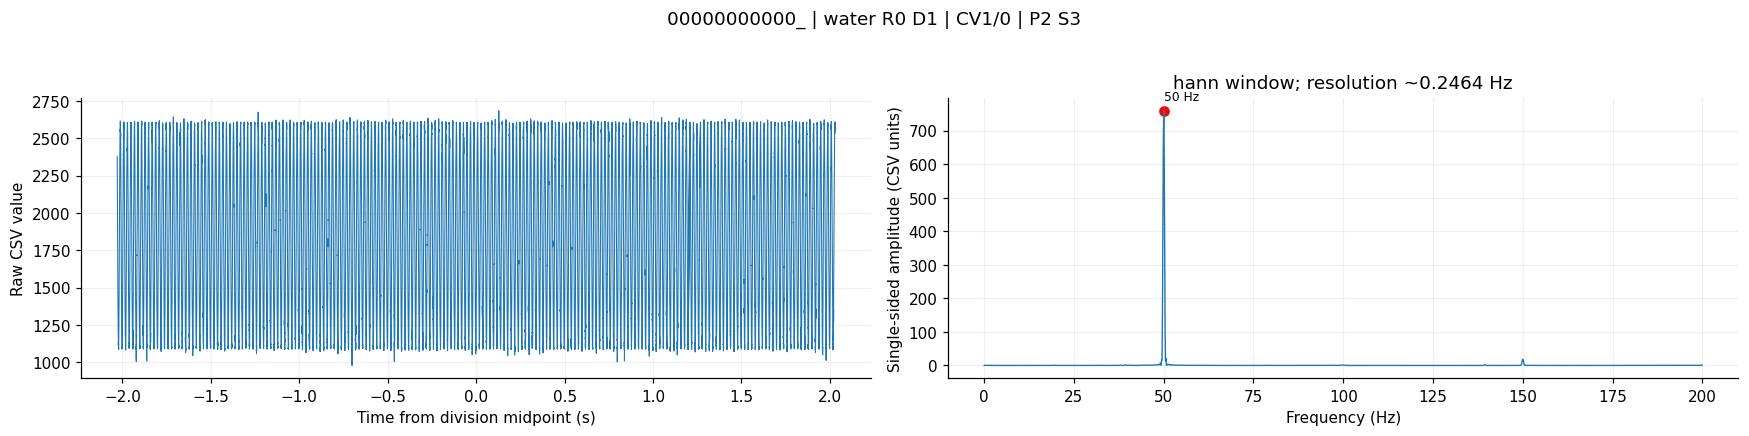

{'info': {'signal': 'CV1',
  'column': '0',
  'pump_id': '2',
  'sample_id': '3',
  'division': 1,
  'samples': 109371,
  'sampling_rate_hz': 26947.278137144214,
  'start_row': 156182,
  'end_row_exclusive': 265553,
  'duration_s': 4.05870305132015,
  'division_duration_s': 4.05870305132015,
  'common_duration_s': 12.176044574181617,
  'title': '00000000000_ | water R0 D1 | CV1/0 | P2 S3',
  'name': 'CV1_col0_pump2_sample3_d1_n109371'},
 'spectrum':         frequency_hz  amplitude
 0           0.000000   0.084202
 1           0.123192   0.278906
 2           0.246384   0.347179
 3           0.369576   0.272954
 4           0.492768   0.149269
 ...              ...        ...
 109367  13473.146300   0.010531
 109368  13473.269492   0.026468
 109369  13473.392684   0.028403
 109370  13473.515877   0.018996
 109371  13473.639069   0.005440
 
 [109372 rows x 2 columns],
 'peaks':    frequency_hz   amplitude
 0     50.015977  759.924363}

In [44]:
plot_division_fft(SIGNAL, 2,3,1)

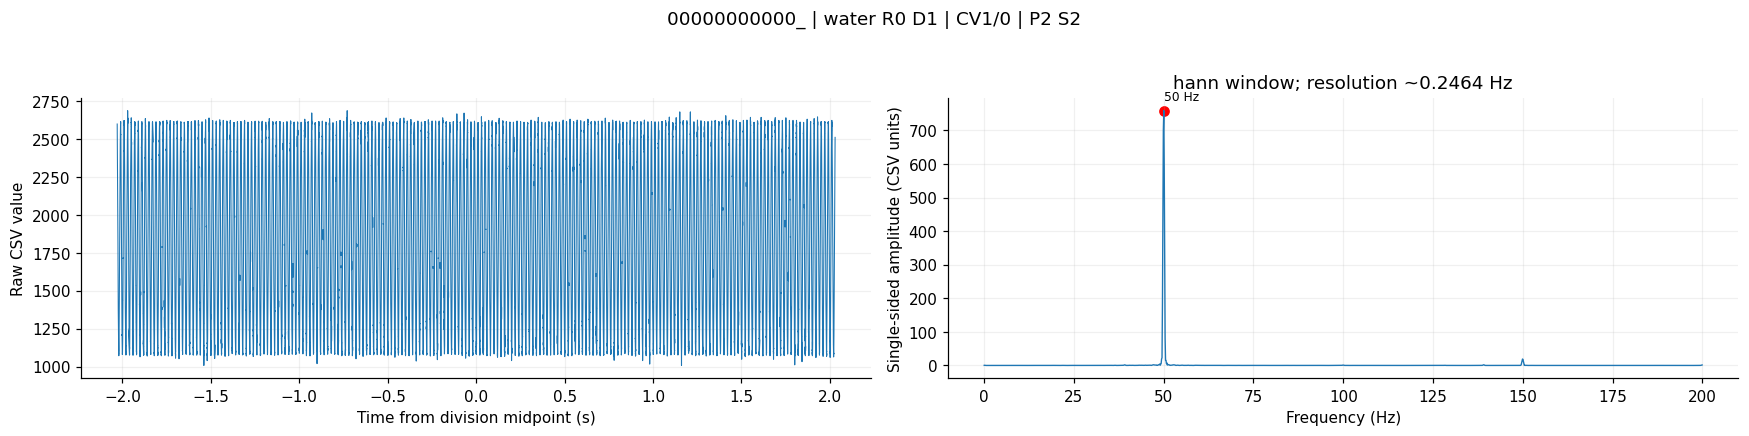

{'info': {'signal': 'CV1',
  'column': '0',
  'pump_id': '2',
  'sample_id': '2',
  'division': 1,
  'samples': 109296,
  'sampling_rate_hz': 26928.968595329818,
  'start_row': 98208,
  'end_row_exclusive': 207504,
  'duration_s': 4.05867753950869,
  'division_duration_s': 4.05867753950869,
  'common_duration_s': 12.176044574181617,
  'title': '00000000000_ | water R0 D1 | CV1/0 | P2 S2',
  'name': 'CV1_col0_pump2_sample2_d1_n109296'},
 'spectrum':         frequency_hz  amplitude
 0           0.000000   0.355048
 1           0.123193   0.589894
 2           0.246386   0.320476
 3           0.369579   0.089288
 4           0.492771   0.018237
 ...              ...        ...
 109292  13463.991526   0.048503
 109293  13464.114719   0.046824
 109294  13464.237912   0.047969
 109295  13464.361105   0.040050
 109296  13464.484298   0.015406
 
 [109297 rows x 2 columns],
 'peaks':    frequency_hz   amplitude
 0     50.016292  758.628669}

In [45]:
plot_division_fft(SIGNAL, 2,2,1)

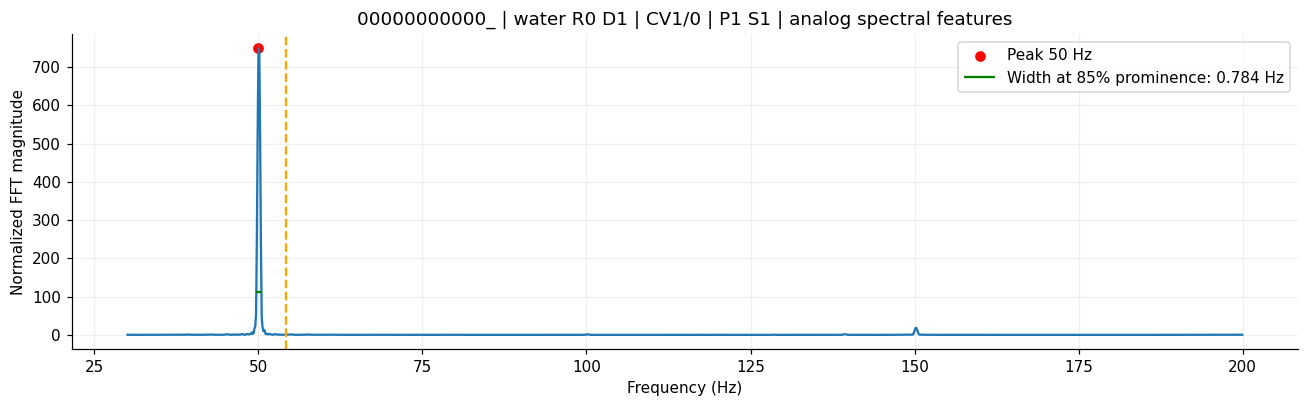

109261 middle samples; duration=4.05867 s; fs=26920.4 Hz


,feature,value
0,peak_freq,5.001643e+01
1,peak_magn_raw,2.044856e+07
2,peak_width_start,4.968168e+01
3,peak_width_end,5.046602e+01
4,peak_width,7.843352e-01
5,gmean,8.785969e-02
6,hmean,4.708833e-02
7,pmean_2,3.618734e+01
8,pmean_3,9.434679e+01
9,fft_kurt,3.265205e+02


In [46]:
def plot_analog_features(signal, pump_id, sample_id, division, n_samples=None,
                         freq_range=(30,200), window='hann'):
    """Analog reference feature family, evaluated on a PUMP division window."""
    x, fs, t, info = _division_window(signal,pump_id,sample_id,division,n_samples)
    freq, raw, amp = _fft_data(x,fs,window)
    mask = _freq_mask(freq,freq_range)
    f, r = freq[mask], raw[mask]
    
    # Reference normalization excludes the first four FFT bins.
    # scale = raw[4:].max() if len(raw)>4 else raw.max()
    # a = r/scale if scale>1e-12 else np.zeros_like(r)
    a = amp[mask]

    peaks,_ = find_peaks(a,height=a.max()*.1)
    
    peak = int(peaks[np.argmax(a[peaks])]) if len(peaks) else None
    left = right = level = np.nan
    if peak is not None:
        widths = peak_widths(a,[peak],rel_height=.85)
        left,right = np.interp([widths[2][0],widths[3][0]],np.arange(len(f)),f)
        level = float(widths[1][0])
    mass = a.sum()
    weights = a/mass if mass>1e-12 else np.zeros_like(a)
    centroid = float(np.sum(f*weights)) if mass>1e-12 else np.nan
    nonconstant = np.ptp(a)>1e-12
    feats = {'peak_freq':float(f[peak]) if peak is not None else np.nan,
             'peak_magn_raw':float(r[peak]) if peak is not None else np.nan,
             'peak_width_start':left,'peak_width_end':right,'peak_width':right-left,
             'gmean':float(gmean(a)),'hmean':float(hmean(a)),
             'pmean_2':float(pmean(a,2)),'pmean_3':float(pmean(a,3)),
             'fft_kurt':float(kurtosis(a)) if nonconstant else np.nan,
             'fft_skew':float(skew(a)) if nonconstant else np.nan,
             'peak_to_median':float(a[peak]/(np.median(a)+1e-12)) if peak is not None else np.nan,
             'peak_energy_ratio':float(r[peak]**2/(np.sum(r**2)+1e-12)) if peak is not None else np.nan,
             'spectral_centroid':centroid,
             'spectral_bandwidth':float(np.sqrt(np.sum((f-centroid)**2*weights))),
             'spectral_entropy':float(entropy(weights+1e-12)) if mass>1e-12 else np.nan}
    fig,ax=plt.subplots(figsize=(12,4))
    ax.plot(f,a)
    if peak is not None:
        ax.scatter(f[peak],a[peak],color='red',label=f'Peak {f[peak]:.3g} Hz')
        ax.hlines(level,left,right,color='green',label=f'Width at 85% prominence: {right-left:.3g} Hz')
        ax.legend()
    ax.axvline(centroid,color='orange',ls='--') if np.isfinite(centroid) else None
    ax.set(title=info['title']+' | analog spectral features',xlabel='Frequency (Hz)',ylabel='Normalized FFT magnitude')
    finish_plot(fig,'analog_'+info['name'])
    return {'info':info,'features':_feature_display(feats,info)}

# Use an electrical SIGNAL/COLUMN, rerun the comparison, then:
result = plot_analog_features(SIGNAL, focus_pump, selected.iloc[0].sample_id, 1)

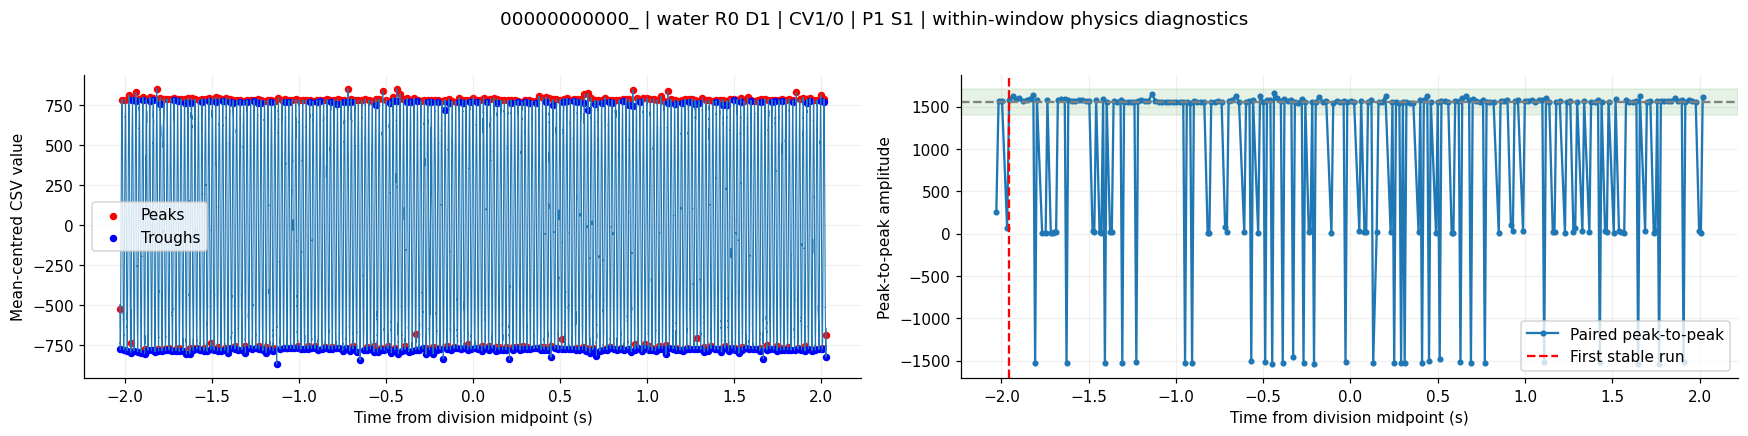

109261 middle samples; duration=4.05867 s; fs=26920.4 Hz


,feature,value
0,peak_count,293.000000
1,trough_count,296.000000
2,paired_cycles,251.000000
3,median_cycle_peak_to_peak,1556.000000
4,steady_peak_to_peak,1557.000000
5,ac_rms,549.801361
6,crest_factor,1.583080
7,settling_time_from_window_start_s,0.073662
8,paired_cycles_before_settling,4.000000


In [47]:
def plot_physics_features(signal, pump_id, sample_id, division, n_samples=None,
                          prominence=.15, min_peak_distance_s=.01,
                          tolerance=.1, consecutive_cycles=5):
    """Peak/trough amplitudes and settling relative to the selected window's start."""
    if prominence < 0 or min_peak_distance_s <= 0 or tolerance < 0:
        raise ValueError('Peak distance must be positive; prominence/tolerance nonnegative')
    if not isinstance(consecutive_cycles,int) or consecutive_cycles<1:
        raise ValueError('consecutive_cycles must be a positive integer')
    x,fs,t,info = _division_window(signal,pump_id,sample_id,division,n_samples)
    y=x-x.mean()
    distance=max(1,int(round(min_peak_distance_s*fs)))
    peaks,_=find_peaks(y,prominence=prominence,distance=distance)
    troughs,_=find_peaks(-y,prominence=prominence,distance=distance)
    # Match each peak to its following trough before the next peak.
    pairs=[]
    for i,p in enumerate(peaks):
        stop=peaks[i+1] if i+1<len(peaks) else len(y)
        candidates=troughs[(troughs>p)&(troughs<stop)]
        if len(candidates): pairs.append((int(p),int(candidates[np.argmin(y[candidates])])) )
    pp=np.array([a for a,b in pairs],dtype=int)
    tt=np.array([b for a,b in pairs],dtype=int)
    amplitudes=y[pp]-y[tt]
    steady=float(np.median(amplitudes[-5:])) if len(amplitudes) else np.nan
    stable=None
    if np.isfinite(steady) and steady>1e-12:
        error=np.abs(amplitudes-steady)/steady
        for i in range(len(error)-consecutive_cycles+1):
            if np.all(error[i:i+consecutive_cycles]<=tolerance):
                stable=i; break
    rms=float(np.sqrt(np.mean(y*y)))
    feats={'peak_count':len(peaks),'trough_count':len(troughs),'paired_cycles':len(pairs),
           'median_cycle_peak_to_peak':float(np.median(amplitudes)) if len(amplitudes) else np.nan,
           'steady_peak_to_peak':steady,'ac_rms':rms,
           'crest_factor':float(np.max(np.abs(y))/rms) if rms>1e-12 else np.nan,
           'settling_time_from_window_start_s':float(pp[stable]/fs) if stable is not None else np.nan,
           'paired_cycles_before_settling':stable if stable is not None else np.nan}
    fig,axes=plt.subplots(1,2,figsize=(16,4))
    axes[0].plot(t,y,lw=.7)
    axes[0].scatter(t[peaks],y[peaks],s=15,c='red',label='Peaks')
    axes[0].scatter(t[troughs],y[troughs],s=15,c='blue',label='Troughs')
    axes[0].set(xlabel='Time from division midpoint (s)',ylabel='Mean-centred CSV value')
    axes[0].legend()
    axes[1].plot(t[pp],amplitudes,'o-',ms=3,label='Paired peak-to-peak')
    if np.isfinite(steady):
        axes[1].axhline(steady,color='grey',ls='--')
        axes[1].axhspan(steady*(1-tolerance),steady*(1+tolerance),alpha=.1,color='green')
    if stable is not None:
        axes[1].axvline(t[pp[stable]],color='red',ls='--',label='First stable run')
    axes[1].set(xlabel='Time from division midpoint (s)',ylabel='Peak-to-peak amplitude')
    axes[1].legend()
    fig.suptitle(info['title']+' | within-window physics diagnostics')
    finish_plot(fig,'physics_'+info['name'])
    return {'info':info,'features':_feature_display(feats,info),
            'cycles':pd.DataFrame({'time_s':t[pp],'peak_to_peak':amplitudes})}

result = plot_physics_features(SIGNAL, focus_pump, selected.iloc[0].sample_id, 1)

In [48]:
def bandpower(lo, hi, freqs, mag):
    mask = (freqs >= lo) & (freqs < hi)
    _fft = mag[mask]
    _fft_freq = freqs[mask]
    if len(_fft) == 0:
        return [0.0, 0.0, 0.0, 0.0, 0.0]
    peak_indices, _ = find_peaks(_fft, height=np.max(_fft) * 0.1)
    if len(peak_indices) == 0:
        top_idx = np.argmax(_fft)
        top_peak_freqs = _fft_freq[top_idx]
        top_peak_mags = _fft[top_idx]
    else:
        peak_freqs = _fft_freq[peak_indices]
        peak_mags = _fft[peak_indices]
        top_peaks_idx = np.argmax(peak_mags)
        top_peak_freqs = peak_freqs[top_peaks_idx]
        top_peak_mags = peak_mags[top_peaks_idx]
    band_power = float(np.sum(_fft ** 2))
    total_power = float(np.sum(mag ** 2)) + 1e-12
    relative_band_power = band_power / total_power
    peak_to_median = float(top_peak_mags / (np.median(_fft) + 1e-12))
    return [float(top_peak_freqs), float(top_peak_mags), band_power, float(relative_band_power), peak_to_median]

def compute_freq_features(key: str, x: np.ndarray, fs: float) -> dict:
    N = len(x)
    freqs = rfftfreq(N, 1 / fs)[:N // 2]
    mag = np.abs(rfft(x))[:N // 2]
    max_mag = np.max(mag)
    if max_mag > 1e-12:
        mag = mag / max_mag
    else:
        mag = np.zeros_like(mag)
    mean_, std_ = (mag.mean(), mag.std())
    skew_, kurt = (skew(mag), kurtosis(mag))
    p = mag / (mag.sum() + 1e-12)
    entropy = -np.sum(p * np.log2(p + 1e-12))
    peak_idx = mag.argmax()
    peak_freq = freqs[peak_idx]
    centroid = np.sum(freqs * mag) / (mag.sum() + 1e-12)
    return (freqs, mag, {f'{key}_fft_mean': float(mean_), f'{key}_fft_std': float(std_), f'{key}_fft_skew': float(skew_), f'{key}_fft_kurtosis': float(kurt), f'{key}_fft_entropy': float(entropy), f'{key}_spectral_centroid': float(centroid)})

def compute_cwt_features(key: str, x: np.ndarray, fs: float, wavelet: str='cmor1.5-1.0', scales: np.ndarray=np.arange(1, 128)) -> tuple:
    coeffs, freqs = pywt.cwt(x, scales, wavelet, sampling_period=1 / fs)
    power = np.abs(coeffs)
    power **= 2
    del coeffs
    max_power = float(power.max())
    raw_power_sum = float(power.sum())
    if max_power <= 1e-12:
        power.fill(0.0)
    else:
        power /= max_power
    total = power.sum()
    p = power / (total + 1e-12)
    entropy = -np.sum(p * np.log2(p + 1e-12))
    del p
    feats = {f'{key}_wavelet_mean_energy': float(power.mean()), f'{key}_wavelet_std_energy': float(power.std()), f'{key}_wavelet_max_energy': float(max_power), f'{key}_wavelet_max_energy_ratio': float(max_power / (raw_power_sum + 1e-12)), f'{key}_wavelet_entropy': float(entropy)}
    return (freqs, power, feats)

def temporal_modulation_features(power: np.ndarray, key='') -> dict:
    e = power if power.ndim == 1 else power.mean(axis=0)
    threshold = e.mean() + e.std()
    peaks, _ = find_peaks(e, height=threshold)
    intervals = np.diff(peaks) if len(peaks) > 1 else np.array([])
    return {f'{key}_num_spikes': float(len(peaks)), f'{key}_mean_spike_interval': float(intervals.mean() if intervals.size else 0.0), f'{key}_std_spike_interval': float(intervals.std() if intervals.size else 0.0), f'{key}_spike_energy_ratio': float(e[peaks].sum() / (e.sum() + 1e-12))}

def tf_contrast_features(key, power: np.ndarray) -> dict:
    row = power.mean(axis=1)
    col = power.mean(axis=0)
    return {f'{key}_contrast_freq': float(row.std() / (row.mean() + 1e-12)), f'{key}_contrast_time': float(col.std() / (col.mean() + 1e-12))}

In [49]:
def plot_digital_features(signal, pump_id, sample_id, division, n_samples=None,
                          filter_band=(10,500), bands=((75,125),(175,225)),
                          include_wavelet=False, scales=None, max_wavelet_samples=16384):
    """Reference FFT/band features; optional bounded-memory wavelet diagnostics."""
    if signal.upper() not in ('AC1','GYR'):
        raise ValueError('Use AC1 or GYR for the digital vibration feature family')
    x,fs,t,info=_division_window(signal,pump_id,sample_id,division,n_samples)
    bands=tuple(tuple(map(float,b)) for b in bands)
    if any(not 0<=lo<hi<=fs/2 for lo,hi in bands):
        raise ValueError(f'Every feature band must be within 0..{fs/2:g} Hz')
    if filter_band is not None:
        lo,hi=map(float,filter_band)
        if not 0<lo<hi<fs/2:
            raise ValueError(f'filter_band must satisfy 0 < low < high < {fs/2:g} Hz, or use None')
        x=sosfiltfilt(butter(5,(lo,hi),btype='bandpass',fs=fs,output='sos'),x)
    else:
        x=x-x.mean()
    if np.std(x)<=1e-12:
        raise ValueError('Selected signal is nearly constant after preprocessing')
    key=f'{SIGNAL}_{COLUMN}'
    f,mag,feats=compute_freq_features(key,x,fs)
    band_rows=[]
    for lo,hi in bands:
        if not np.any((f>=lo)&(f<hi)):
            raise ValueError('No FFT bin in a requested band; use more samples or wider bands')
        values=bandpower(lo,hi,f,mag)
        row={'band':f'{lo:g}-{hi:g} Hz'}
        for name,value in zip(['peak_freq','peak_mag','power','relative_power','peak_to_median'],values):
            row[name]=value; feats[f'{key}_{lo:g}_{hi:g}_{name}']=value
        band_rows.append(row)
    if len(band_rows)>=2:
        feats[key+'_log_band_power_ratio']=float(np.log((band_rows[0]['relative_power']+1e-12)/(band_rows[1]['relative_power']+1e-12)))
    for rank,idx in enumerate(sorted(range(len(band_rows)),key=lambda i:band_rows[i]['peak_mag'],reverse=True)):
        feats[f'{key}_rank_{band_rows[idx]["band"]}']=rank
    fig,axes=plt.subplots(1,2,figsize=(16,4))
    axes[0].plot(f,mag)
    for lo,hi in bands: axes[0].axvspan(lo,hi,alpha=.15)
    axes[0].set(xlabel='Frequency (Hz)',ylabel='Normalized FFT magnitude')
    if filter_band is not None: axes[0].set_xlim(0,min(fs/2,filter_band[1]*1.1))
    axes[1].bar([r['band'] for r in band_rows],[r['relative_power'] for r in band_rows])
    axes[1].set(ylabel='Relative FFT band power',xlabel='Frequency band')
    fig.suptitle(info['title']+' | digital FFT/band features')
    finish_plot(fig,'digital_'+info['name'])
    if include_wavelet:
        import pywt
        # Reference helpers resolve pywt at runtime; no mandatory dependency for FFT-only use.
        globals()['pywt']=pywt
        if len(x)>max_wavelet_samples:
            raise ValueError(f'Wavelet limited to {max_wavelet_samples} rows. Pass n_samples <= this limit; no automatic downsampling.')
        scales=np.arange(1,128) if scales is None else np.asarray(scales,dtype=float)
        if scales.ndim!=1 or not len(scales) or not np.isfinite(scales).all() or np.any(scales<=0):
            raise ValueError('scales must be a nonempty vector of positive finite numbers')
        if len(scales)*len(x)>4_000_000:
            raise ValueError('Too many wavelet coefficients; reduce scales or n_samples')
        wf,power,wfeats=compute_cwt_features(key,x,fs,scales=scales)
        feats.update(wfeats); feats.update(tf_contrast_features(key,power))
        for lo,hi in bands:
            mask=(wf>=lo)&(wf<=hi)
            prefix=f'{key}_{lo:g}_{hi:g}'
            if mask.any(): feats.update(temporal_modulation_features(power[mask],prefix))
            else:
                print(f'No wavelet scales cover {lo:g}-{hi:g} Hz; corresponding temporal features are NaN.')
                feats.update({prefix+'_'+s:np.nan for s in ['num_spikes','mean_spike_interval','std_spike_interval','spike_energy_ratio']})
        order=np.argsort(wf)
        fig,ax=plt.subplots(figsize=(12,4))
        mesh=ax.pcolormesh(t,wf[order],power[order],shading='auto',cmap='magma',rasterized=True)
        ax.set(xlabel='Time from division midpoint (s)',ylabel='Wavelet frequency (Hz)',title=info['title'])
        fig.colorbar(mesh,ax=ax,label='Normalized wavelet power')
        finish_plot(fig,'wavelet_'+info['name'])
    return {'info':info,'features':_feature_display(feats,info),'bands':pd.DataFrame(band_rows)}

# result = plot_digital_features(SIGNAL, focus_pump, selected.iloc[0].sample_id, 1)
# Wavelet example: use middle 4096 rows and install PyWavelets if needed.
result = plot_digital_features(SIGNAL, focus_pump, selected.iloc[0].sample_id, 1,
                               n_samples=4096, include_wavelet=False)

ValueError: Use AC1 or GYR for the digital vibration feature family